# １章１節３項 インパルス応答とノイズ

## 概要
レーダーの原理である相関計算によって受信信号を検知する実装と可視化の例です。

## 使用データ

| 項目 | 使用データなし |
| ---- | ---- | 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# Examples Parameters

freqency = 2 * (1E3 ** 2)
time_sec = 1E-8

wavelength = 0.025
num_sample = 1024 * 3

print(f'- Frequency: {freqency} Hz \n- Time: {time_sec} s \n- Wavelength: {wavelength} m')

times = np.linspace(0, time_sec, num=num_sample)

- Frequency: 2000000.0 Hz 
- Time: 1e-08 s 
- Wavelength: 0.025 m


## impulse Response: Ship Radar

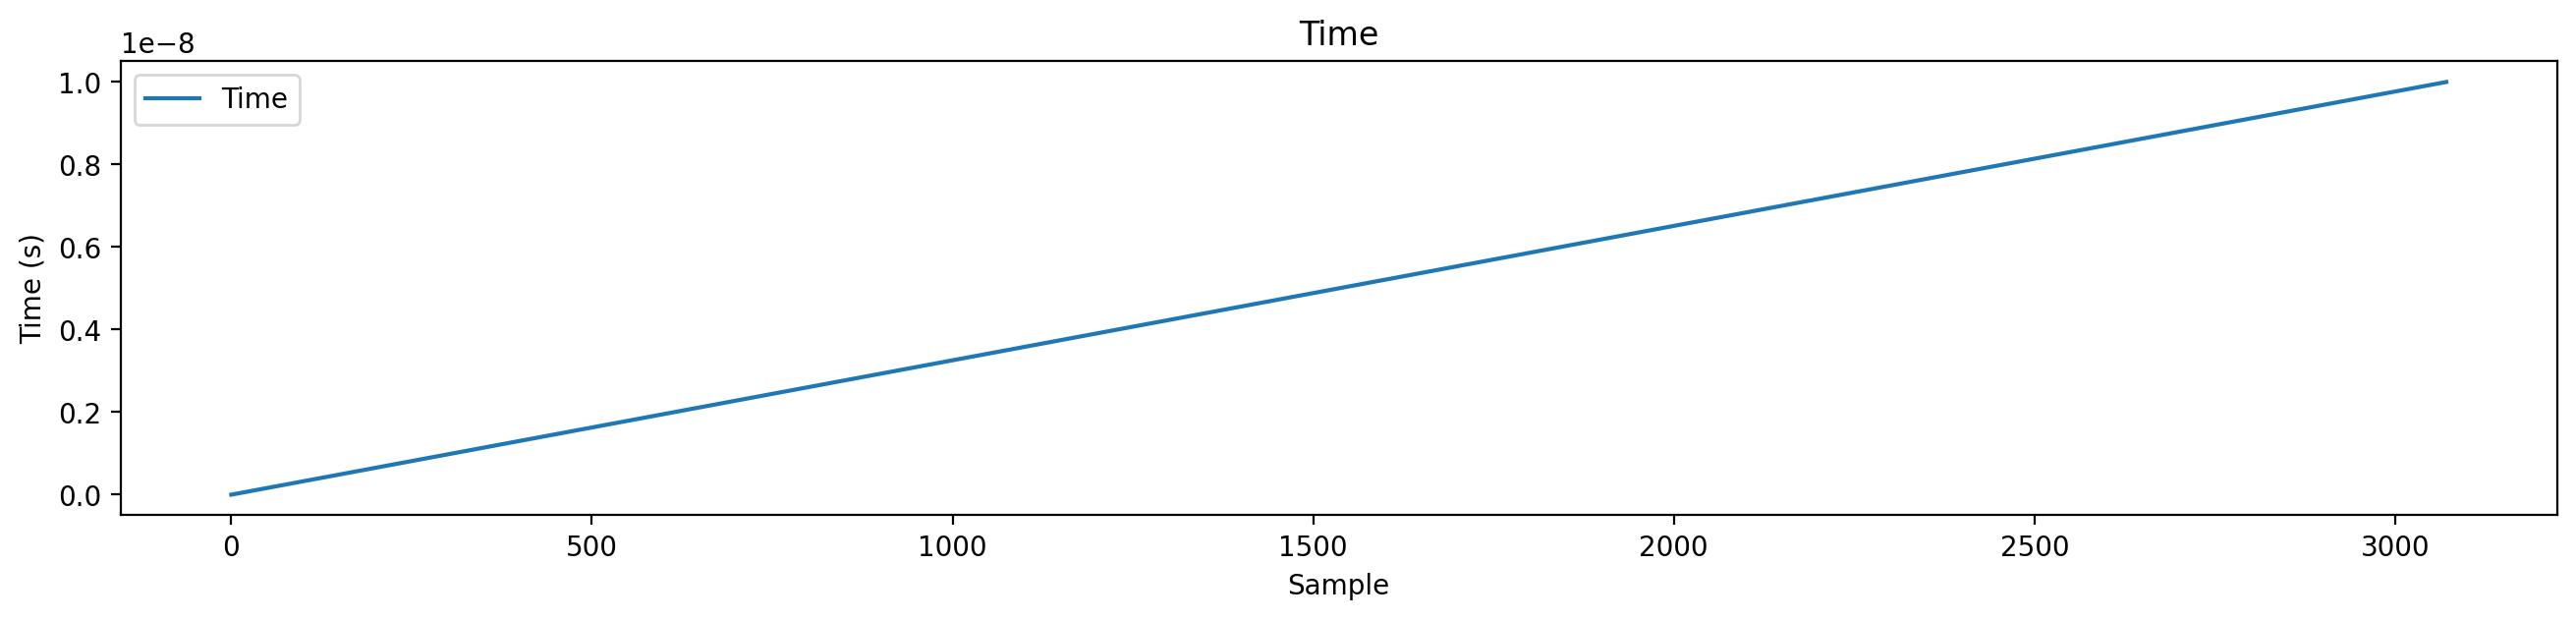

In [3]:
plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Time')
plt.plot(times, label='Time')
plt.legend(loc='upper left',)
plt.xlabel('Sample')
plt.ylabel('Time (s)')
plt.savefig(f'section_03_001_Time.png', bbox_inches='tight')
plt.show()

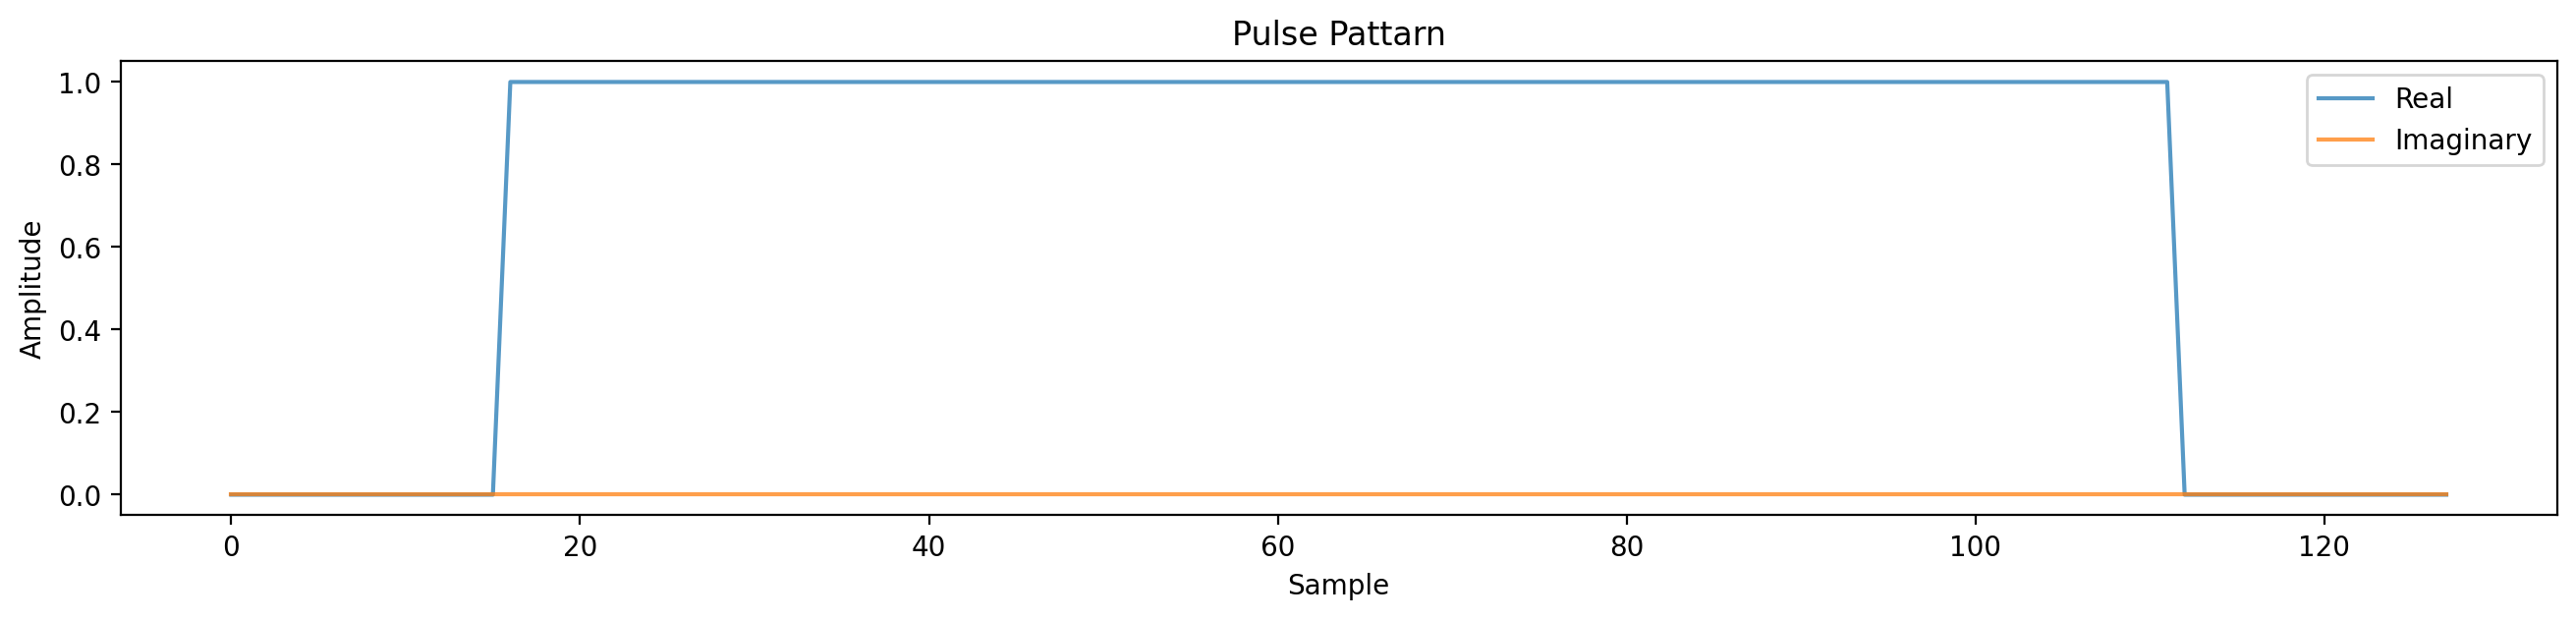

In [4]:
pulse_sample = 128
pulse_times = np.linspace(0, pulse_sample, pulse_sample)

pulse = np.zeros_like(pulse_times, dtype=np.complex64)
pulse[16:128-16] = 1

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Pulse Pattarn')
plt.plot(pulse.real, label='Real', alpha=0.75)
plt.plot(pulse.imag, label='Imaginary', alpha=0.75)
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(f'section_03_002_pulse_pattarn.png', bbox_inches='tight')
plt.show()

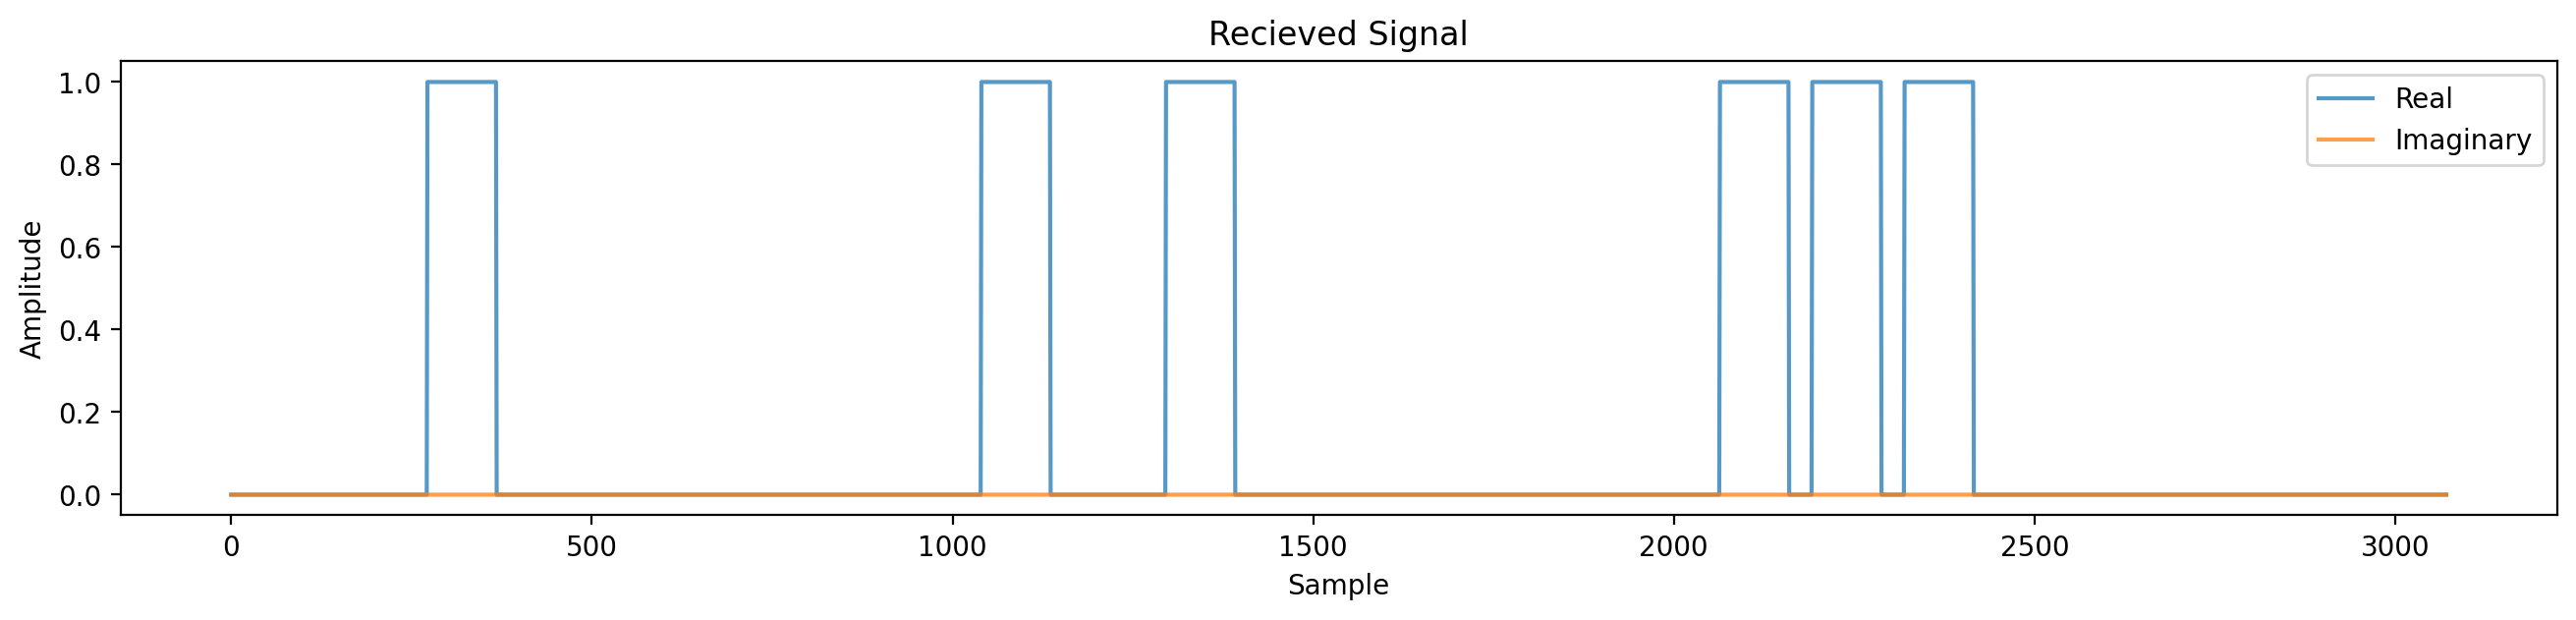

In [5]:
points_pulse = [
    256,
    1024, 1024+256, 
    1024+1024, 1024+1024+128, 1024+1024+256,
]

respons_signal = np.zeros_like(times, dtype=np.complex64)
for point in points_pulse:
    respons_signal[point:point + pulse_sample] += pulse
    
    
plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Recieved Signal')
plt.plot(respons_signal.real, label='Real', alpha=0.75)
plt.plot(respons_signal.imag, label='Imaginary', alpha=0.75)
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(f'section_03_003_recieved_signal.png', bbox_inches='tight')
plt.show()

In [6]:
def impulse_response(respons_signal, pulse):
    
    length_pulse, length_signal = len(pulse), len(respons_signal)
    
    # padding
    _respons_signal = np.zeros((length_pulse+length_signal), dtype=np.complex64)
    _respons_signal[:length_signal] = respons_signal
    
    # process the signal corration
    corr = np.zeros_like(_respons_signal)
    for i in tqdm(range(len(respons_signal))):
        corr[i] = np.sum(np.dot(_respons_signal[i:i+length_pulse] ,np.conj(pulse)))
    corr = np.abs(corr)
    
    return corr[:length_signal]

100%|██████████| 3072/3072 [00:00<00:00, 116230.98it/s]


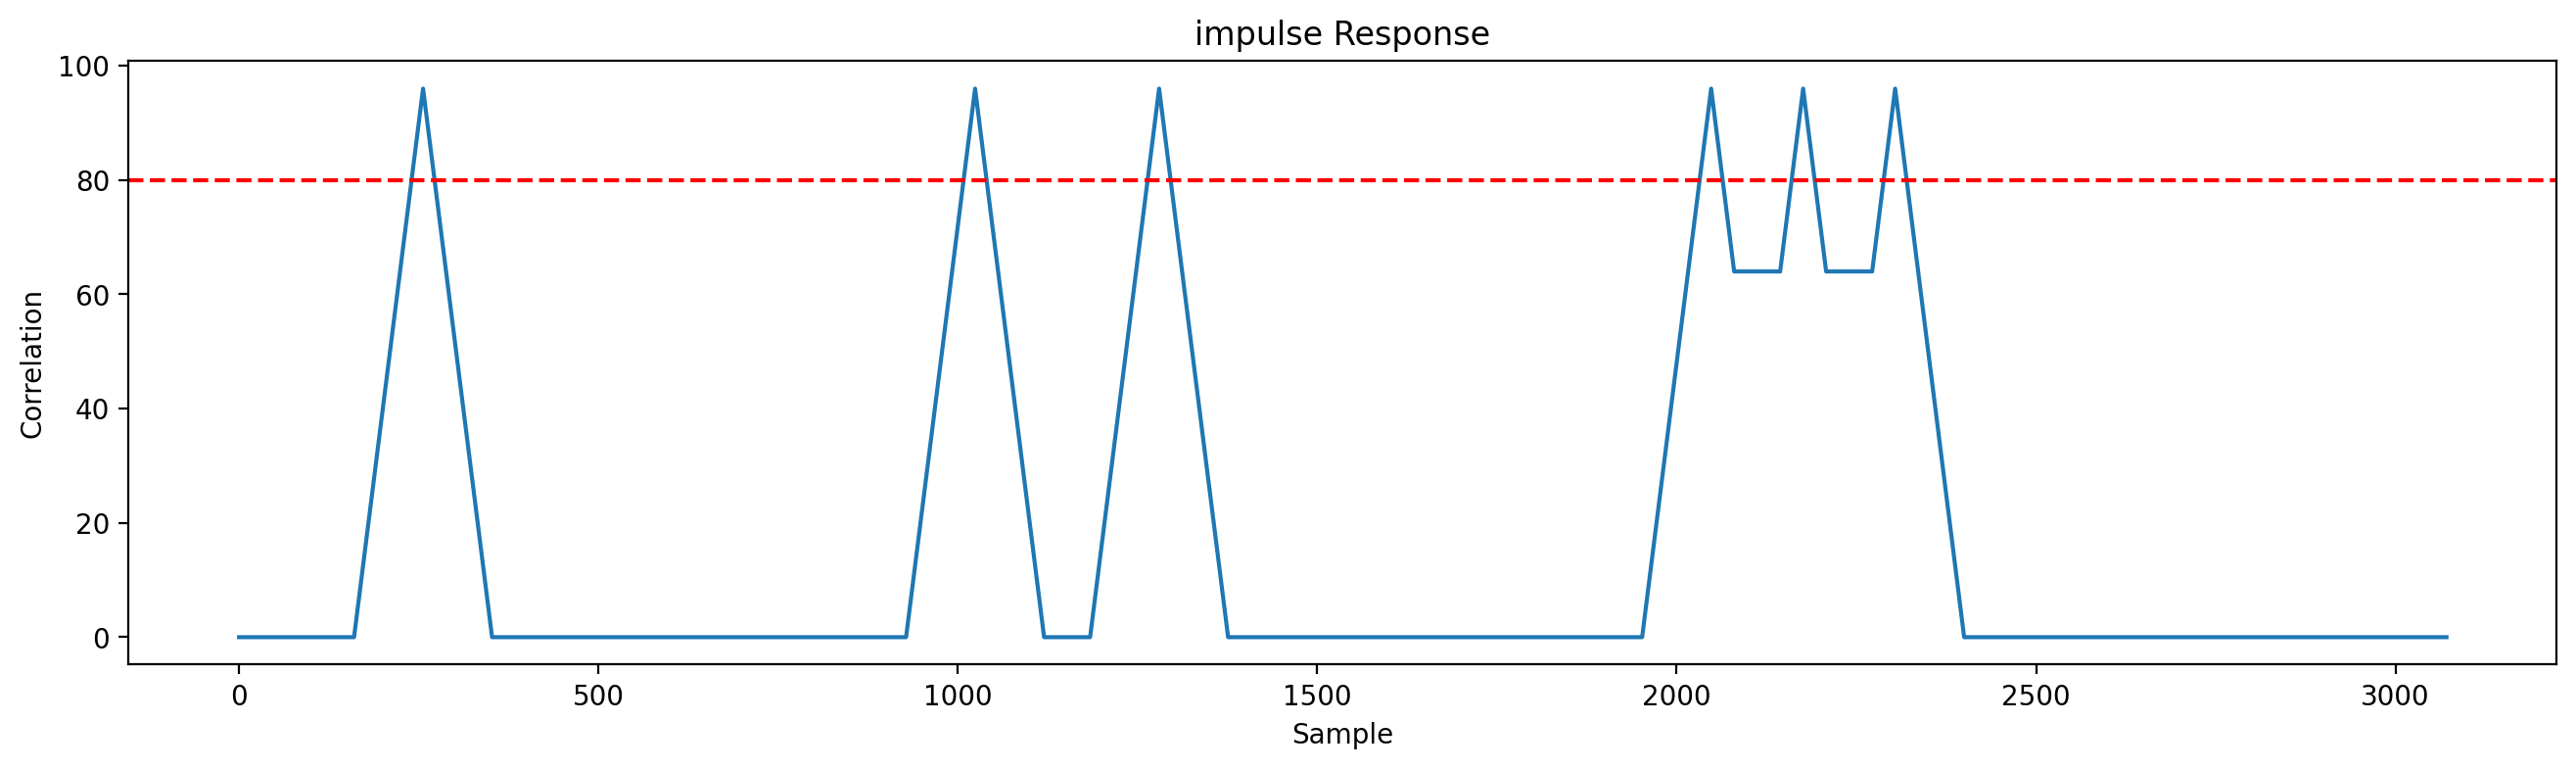

In [8]:
impulse_response_signal = impulse_response(respons_signal, pulse)

plt.figure(figsize=(16, 4), dpi=200, facecolor='w', edgecolor='k')
plt.title('impulse Response')
plt.plot(impulse_response_signal ,)
plt.axhline(80, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_004_impulse_response.png', bbox_inches='tight')
plt.show()

## With Noise 

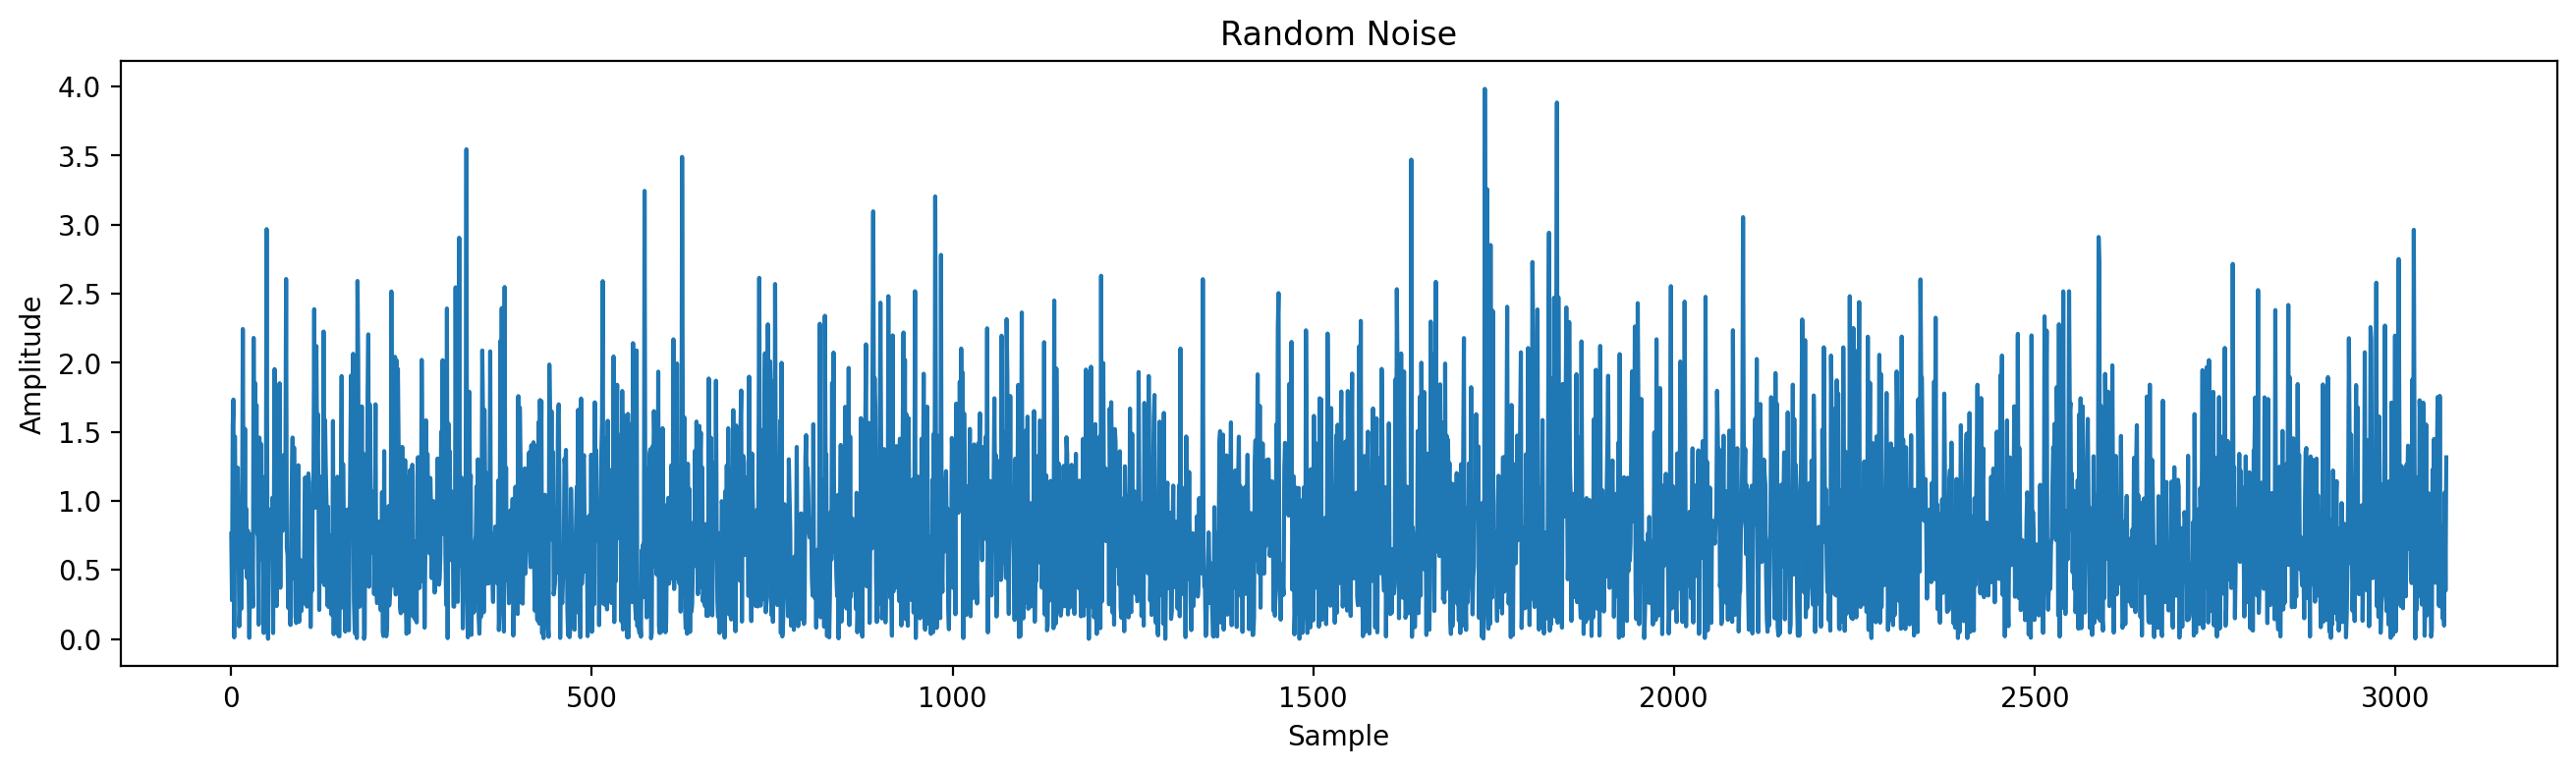

100%|██████████| 3072/3072 [00:00<00:00, 202290.63it/s]


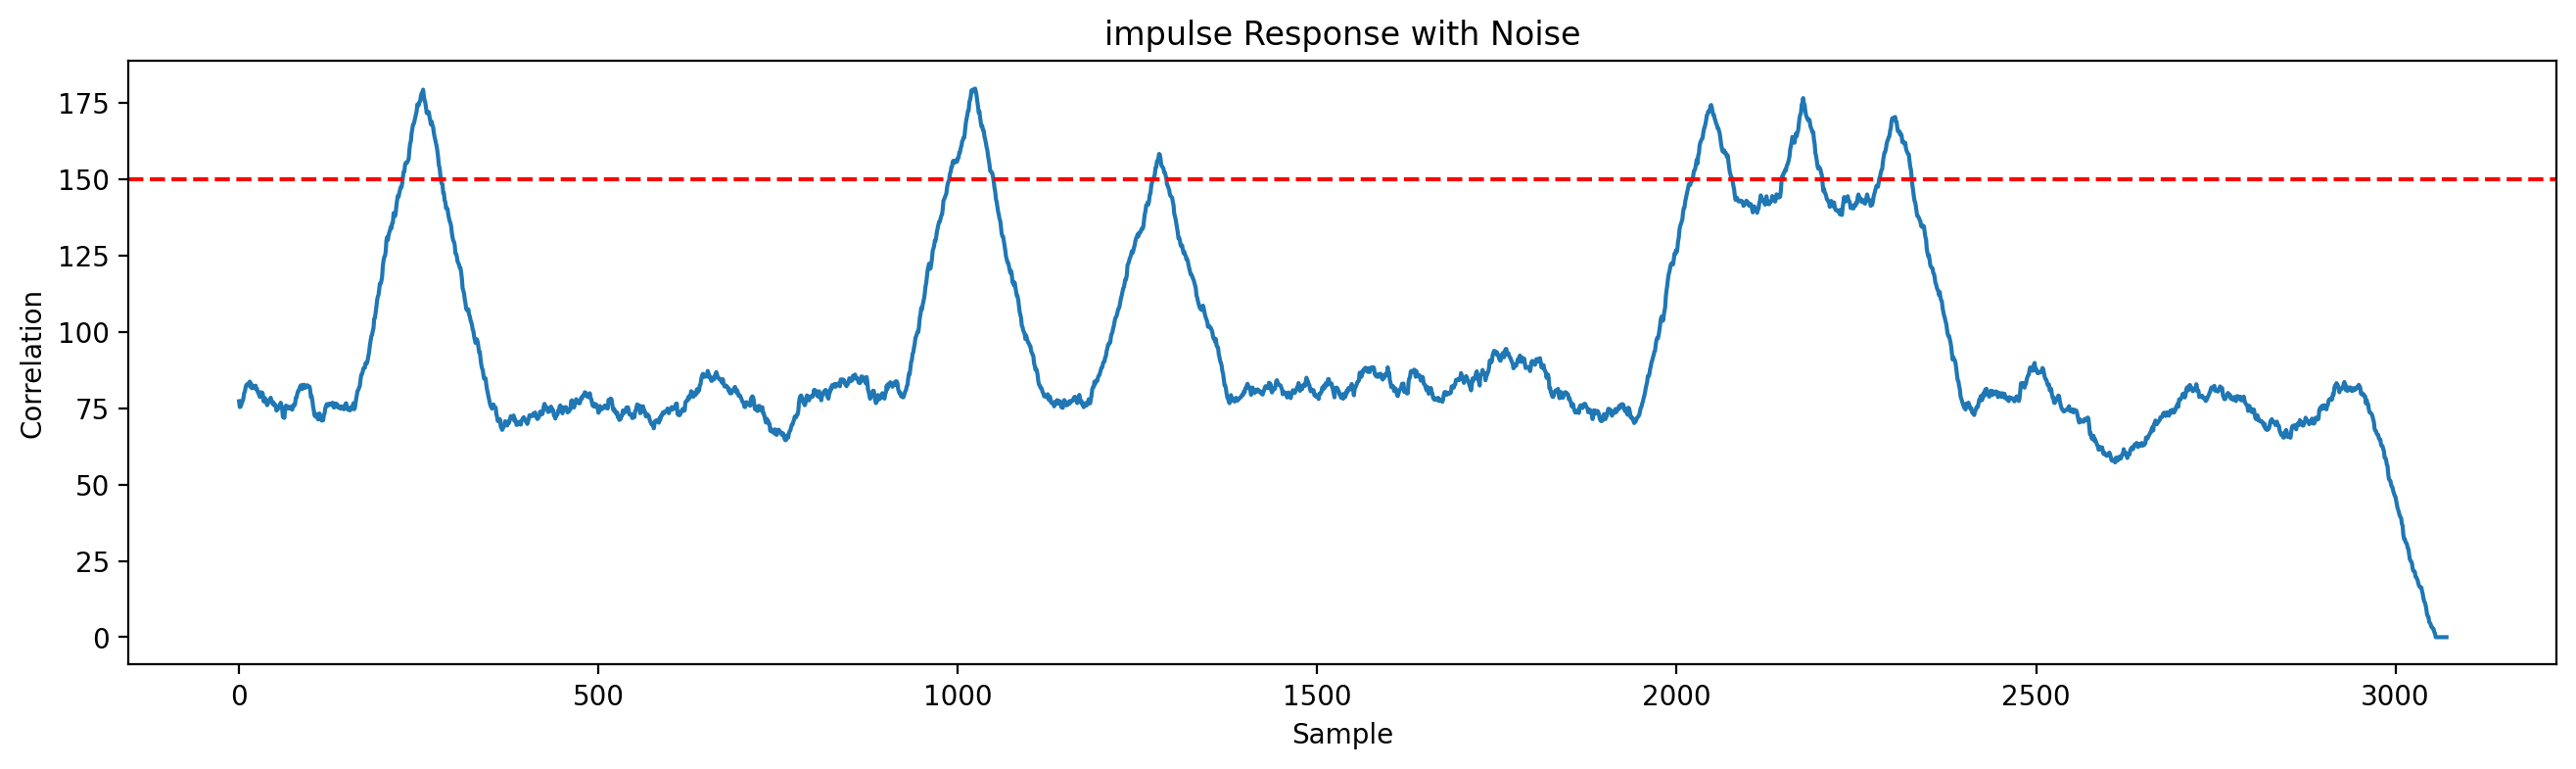

In [9]:
noises = np.random.normal(0, 1, len(impulse_response_signal))
noises = np.abs(noises)

plt.figure(figsize=(16, 4), dpi=200, facecolor='w', edgecolor='k')
plt.title('Random Noise')
plt.plot(noises,)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(f'section_03_005_noise.png', bbox_inches='tight')
plt.show()

impulse_response_signal_noise = impulse_response(respons_signal+ noises, pulse)

plt.figure(figsize=(16, 4), dpi=200, facecolor='w', edgecolor='k')
plt.title('impulse Response with Noise')
plt.plot(impulse_response_signal_noise,)
plt.axhline(150, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_006_impulse_response_with_noise.png', bbox_inches='tight')
plt.show()

100%|██████████| 3072/3072 [00:00<00:00, 189455.99it/s]


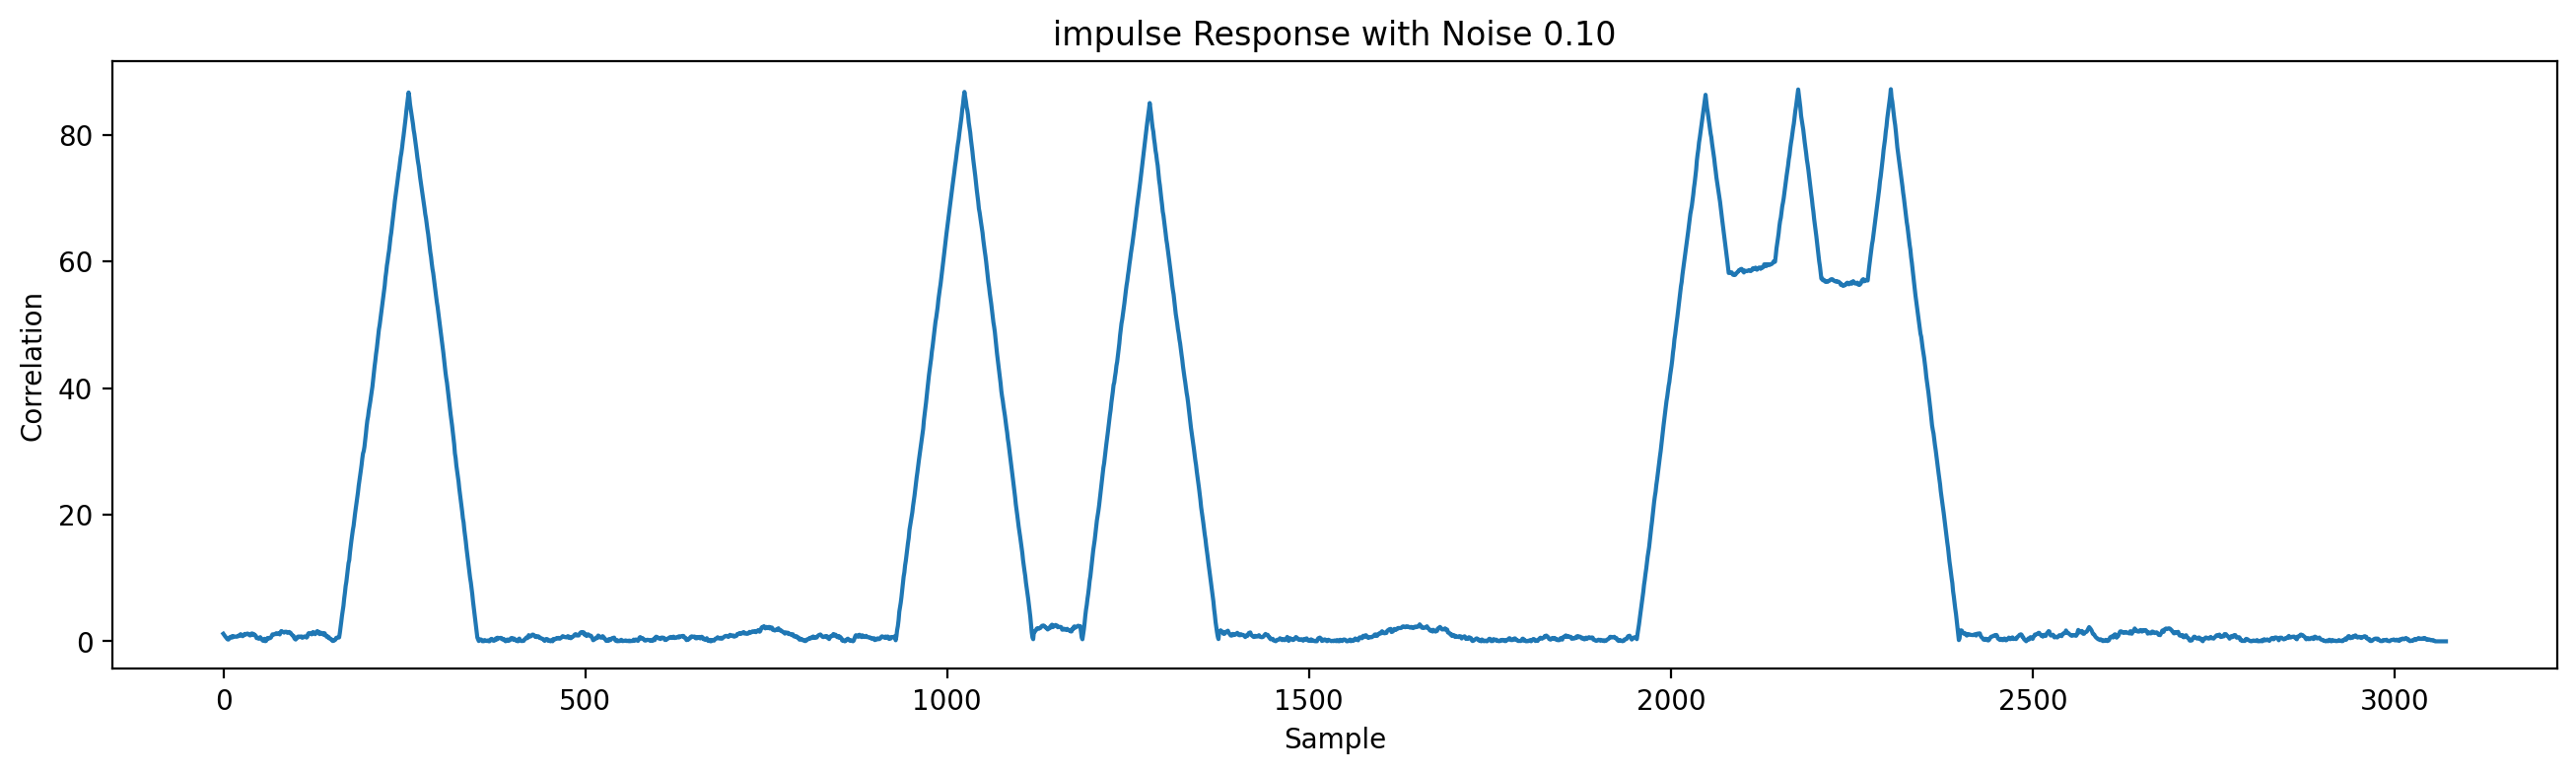

In [9]:
noises = np.random.normal(0, 1, len(impulse_response_signal))
ratio = 0.9 # SNR Ratio

impulse_response_signal_noise = impulse_response(respons_signal *ratio + (1 - ratio) * noises, pulse)

plt.figure(figsize=(16, 4), dpi=200, facecolor='w', edgecolor='k')
plt.title(f'impulse Response with Noise {1 - ratio:.2f}')
plt.plot(impulse_response_signal_noise,)
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_007_impulse_response_with_noise_ratio{ratio:.2f}.png', bbox_inches='tight')
plt.show()

100%|██████████| 3072/3072 [00:00<00:00, 172759.23it/s]


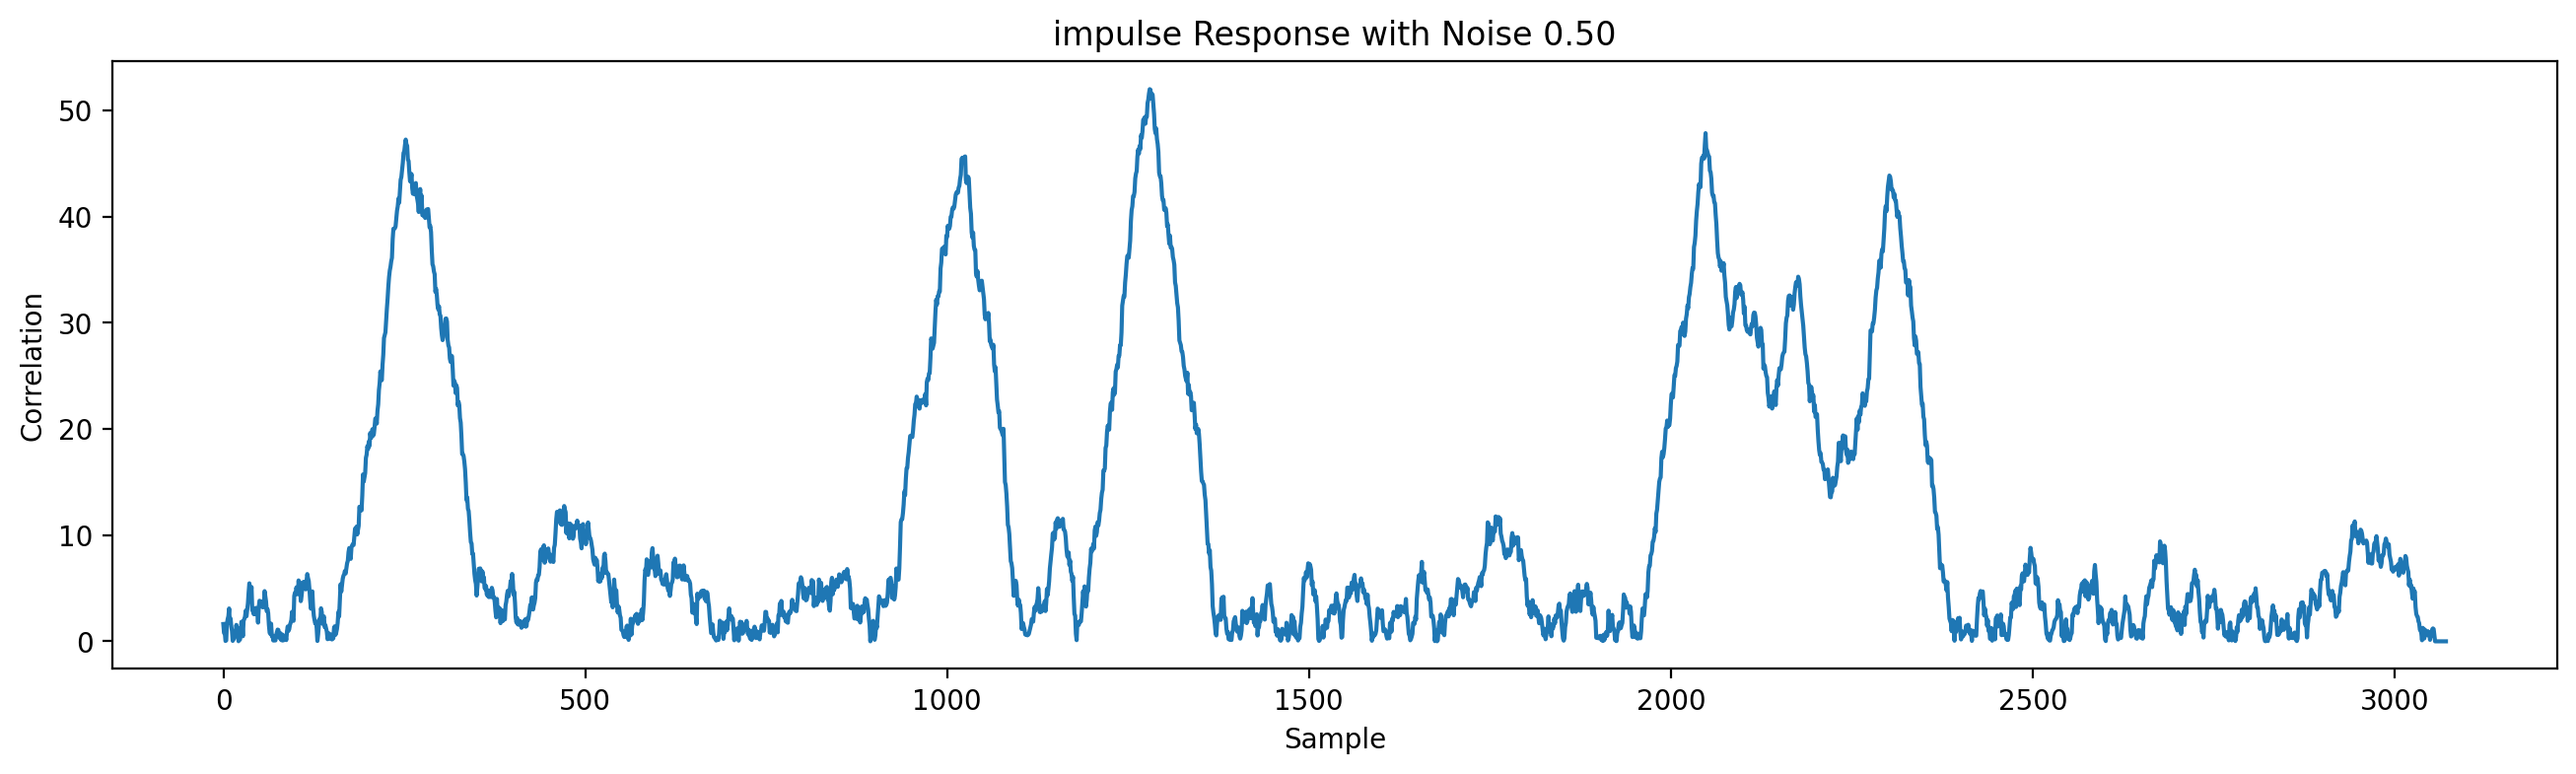

In [10]:
noises = np.random.normal(0, 1, len(impulse_response_signal))
ratio = 0.5 # SNR Ratio

impulse_response_signal_noise = impulse_response(respons_signal *ratio + (1 - ratio) * noises, pulse)

plt.figure(figsize=(16, 4), dpi=200, facecolor='w', edgecolor='k')
plt.title(f'impulse Response with Noise {1 - ratio:.2f}')
plt.plot(impulse_response_signal_noise,)
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_007_impulse_response_with_noise_ratio{ratio:.2f}.png', bbox_inches='tight')
plt.show()

  0%|          | 0/3072 [00:00<?, ?it/s]

100%|██████████| 3072/3072 [00:00<00:00, 87866.98it/s]


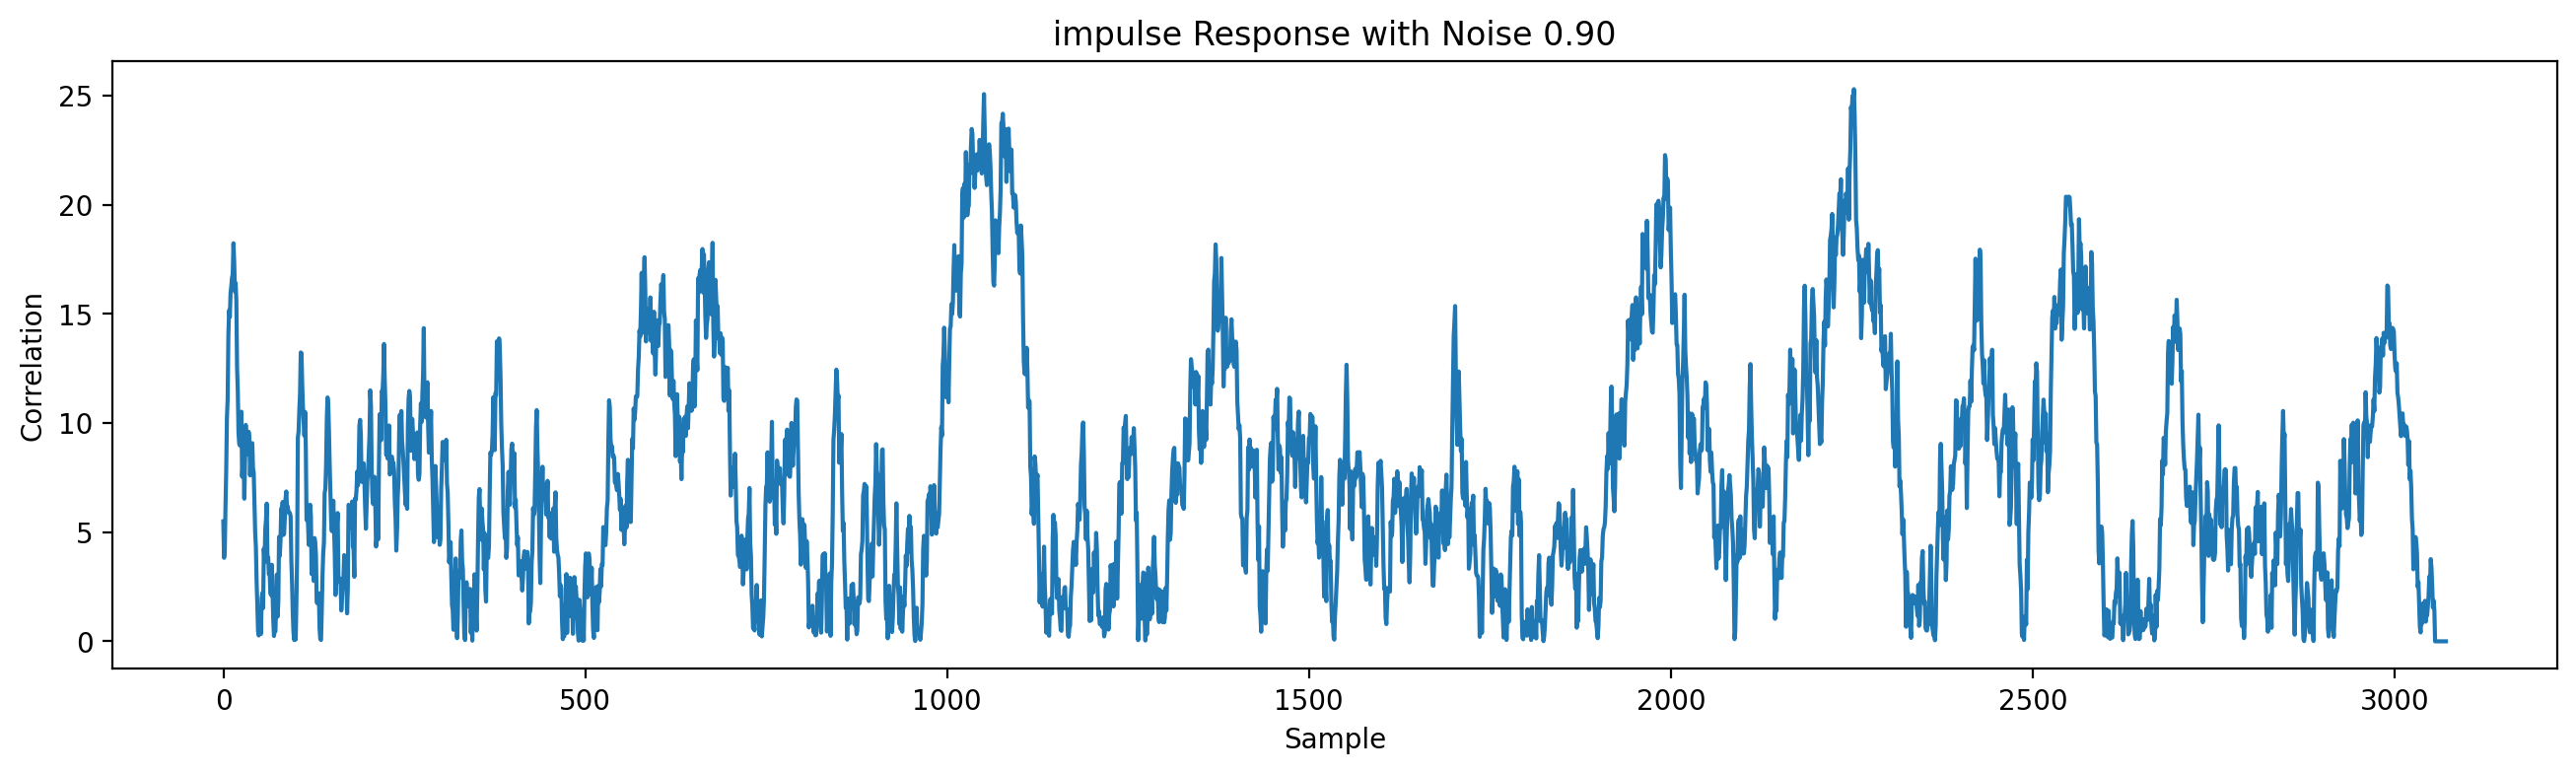

In [11]:
noises = np.random.normal(0, 1, len(impulse_response_signal))
ratio = 0.1 # SNR Ratio

impulse_response_signal_noise = impulse_response(respons_signal *ratio + (1 - ratio) * noises, pulse)

plt.figure(figsize=(16, 4), dpi=200, facecolor='w', edgecolor='k')
plt.title(f'impulse Response with Noise {1 - ratio:.2f}')
plt.plot(impulse_response_signal_noise,)
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_007_impulse_response_with_noise_ratio{ratio:.2f}.png', bbox_inches='tight')
plt.show()

## Chirp Pulse

In [11]:
ratio = 0.25 # SNR Ratio

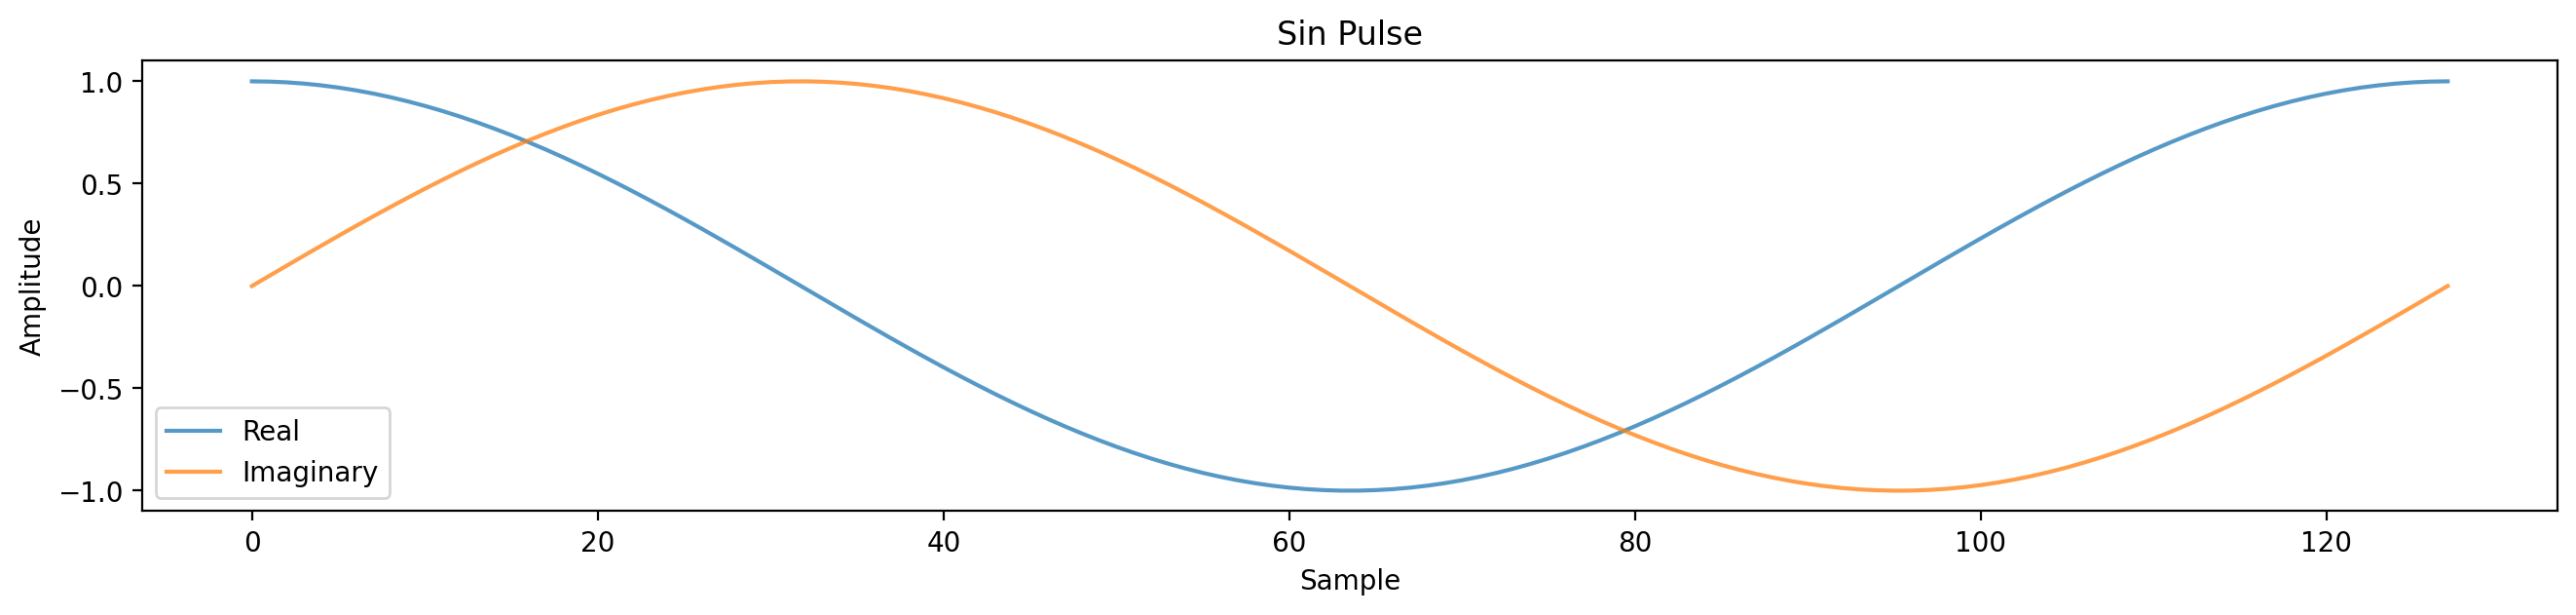

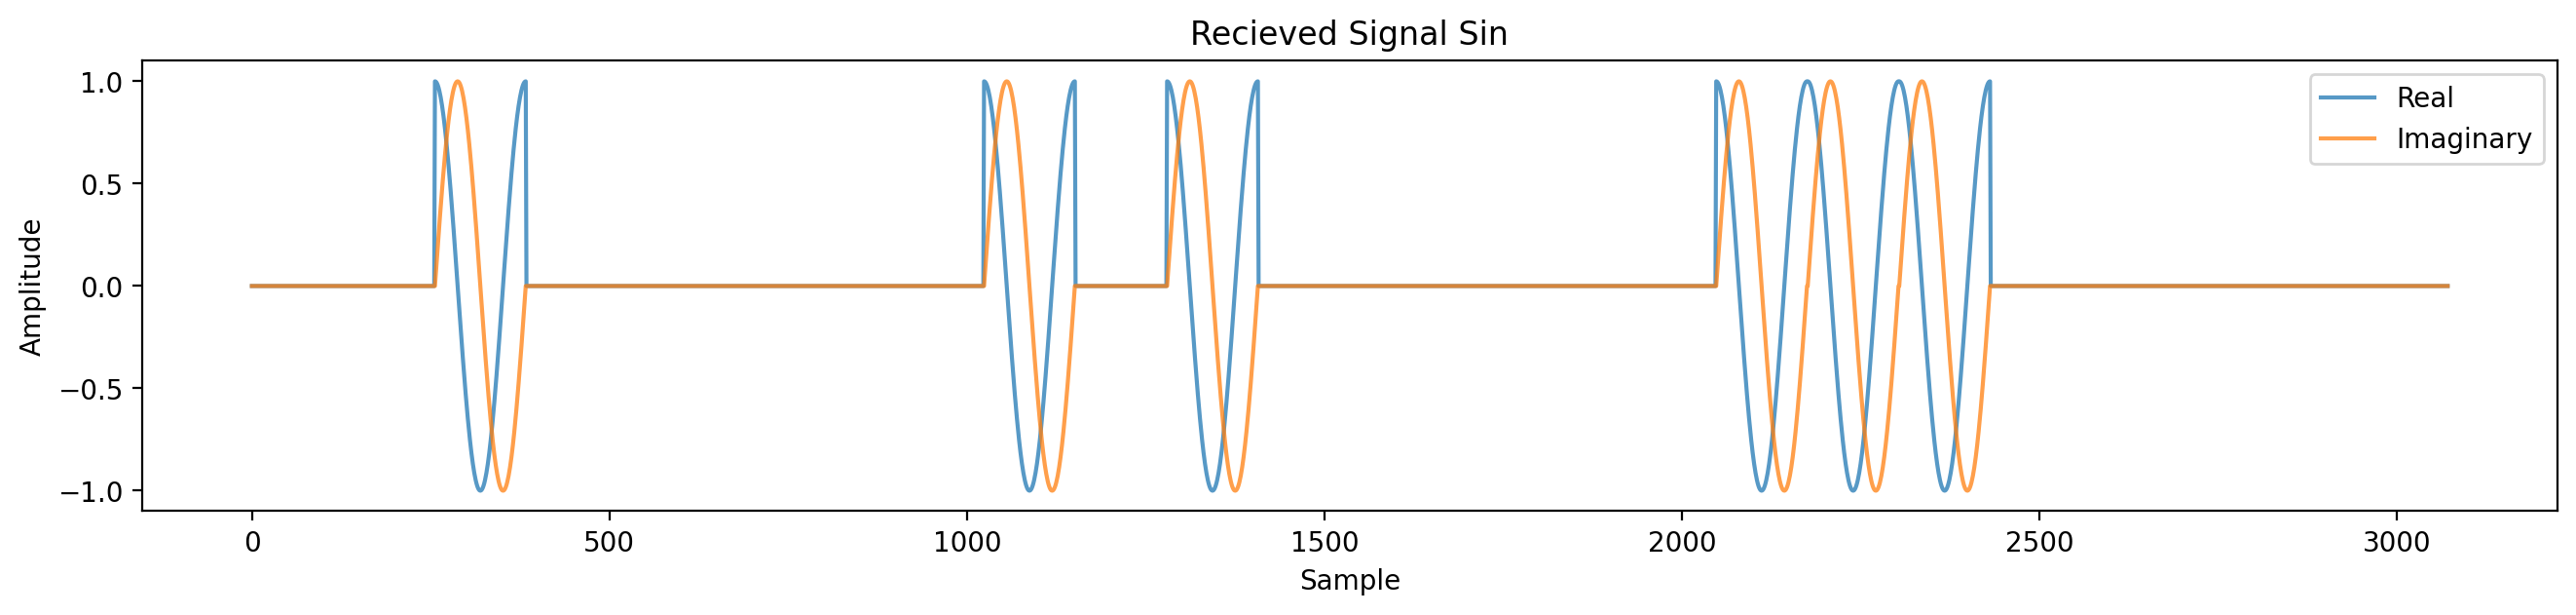

100%|██████████| 3072/3072 [00:00<00:00, 184949.86it/s]


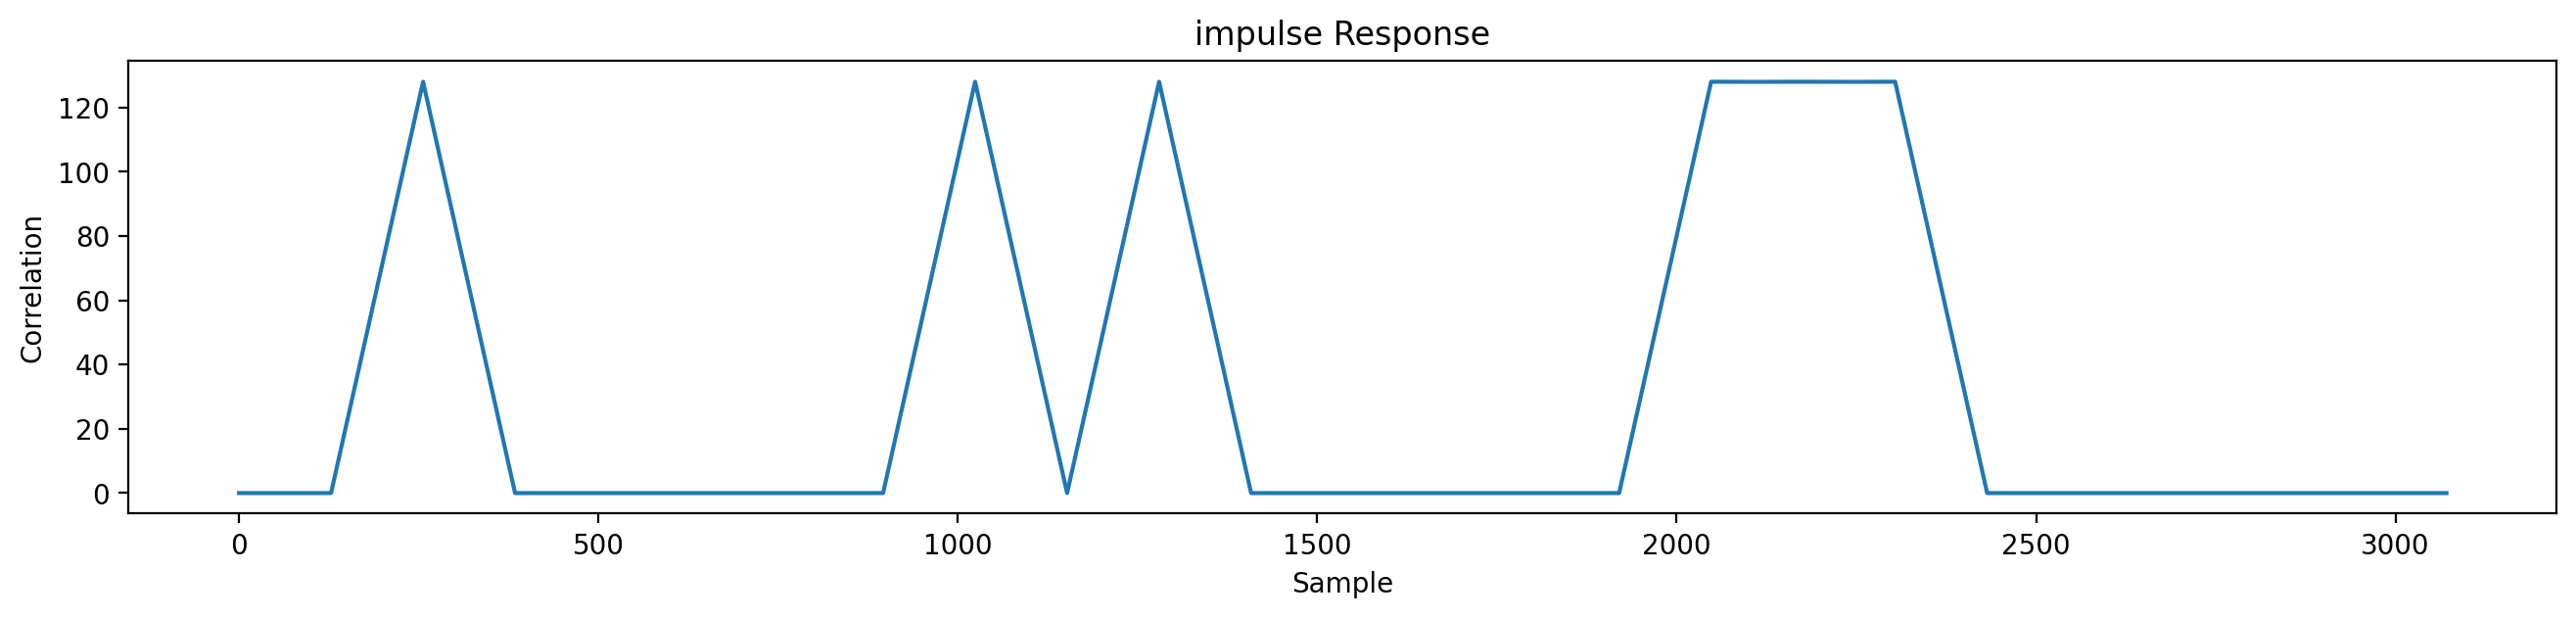

100%|██████████| 3072/3072 [00:00<00:00, 187201.64it/s]


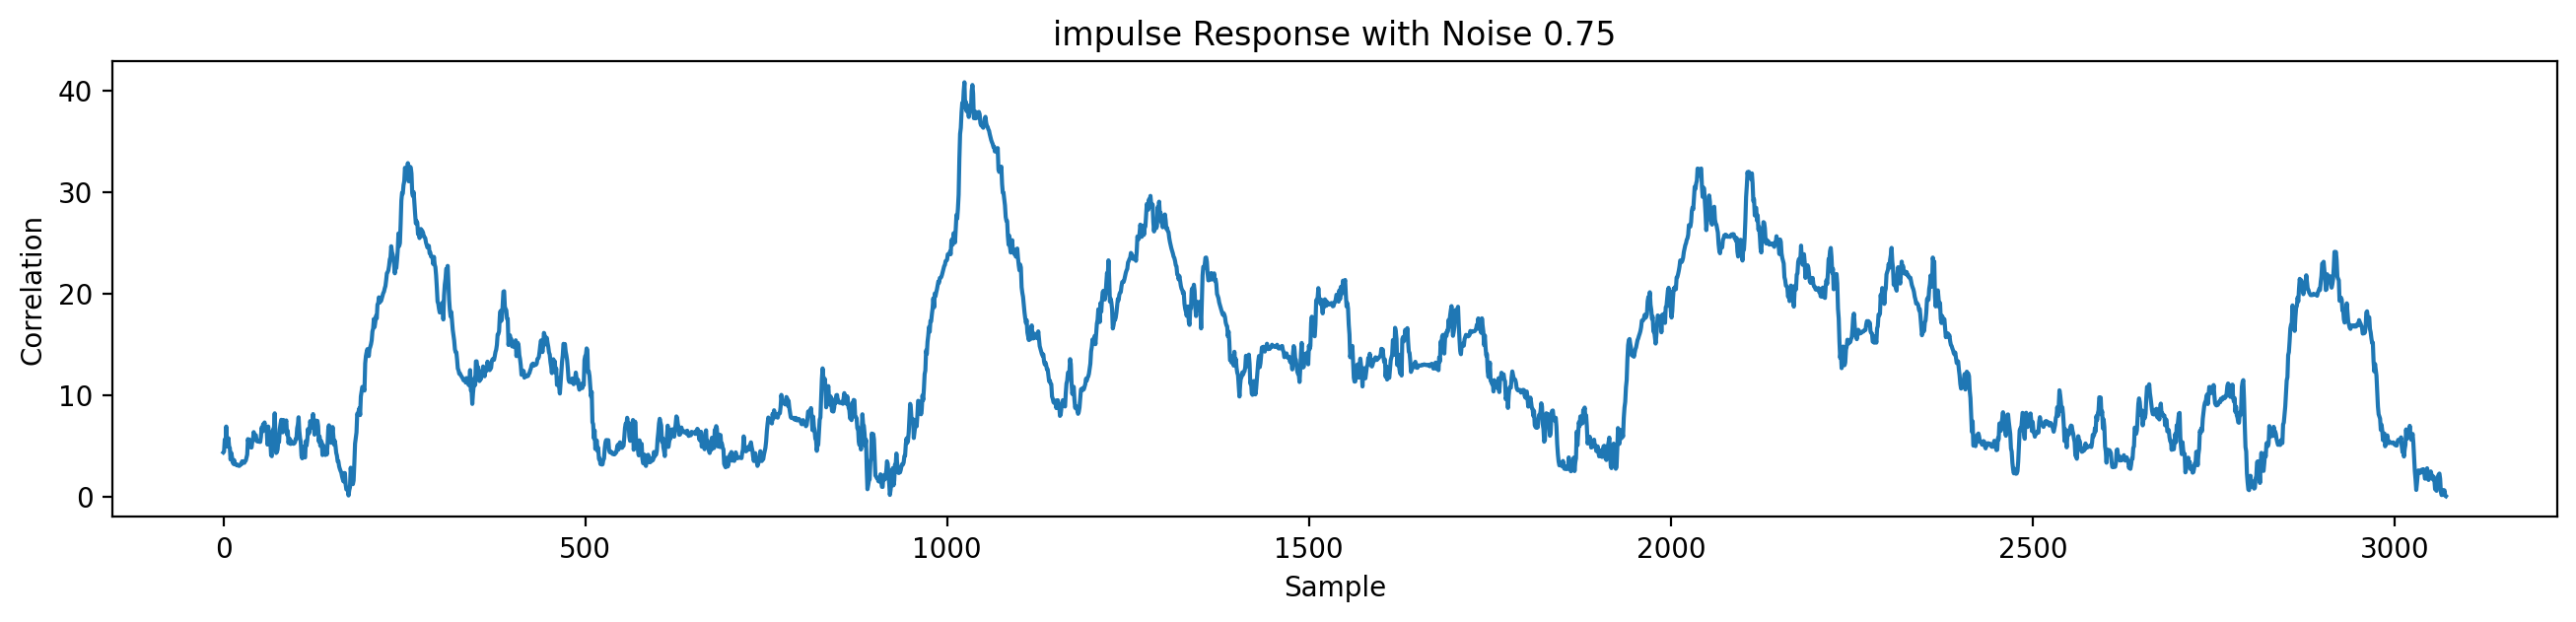

In [13]:
pulse_sample = 128
pulse_times = np.linspace(0, pulse_sample, pulse_sample)
pulse = np.exp(2j * np.pi * pulse_times)

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Sin Pulse')
plt.plot(pulse.real, label='Real', alpha=0.75)
plt.plot(pulse.imag, label='Imaginary', alpha=0.75)
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(f'section_03_008_sin_pulse.png', bbox_inches='tight')
plt.show()


respons_signal = np.zeros_like(times, dtype=np.complex64)
for point in points_pulse:
    respons_signal[point:point + pulse_sample] += pulse
    
    
plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Recieved Signal Sin')
plt.plot(respons_signal.real, label='Real', alpha=0.75)
plt.plot(respons_signal.imag, label='Imaginary', alpha=0.75)
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(f'section_03_009_recieved_signal_sin.png', bbox_inches='tight')
plt.show()

impulse_response_signal = impulse_response(respons_signal, pulse)

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('impulse Response')
plt.plot(impulse_response_signal,)
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_010_impulse_response_sin.png', bbox_inches='tight')
plt.show()

noises = np.random.normal(0, 1, len(impulse_response_signal))

impulse_response_signal_noise = impulse_response(respons_signal *ratio + (1 - ratio) * noises, pulse)

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title(f'impulse Response with Noise {1 - ratio:.2f}')
plt.plot(impulse_response_signal_noise,)
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_011_impulse_response_sin_with_noise_ratio{ratio:.2f}.png', bbox_inches='tight')
plt.show()

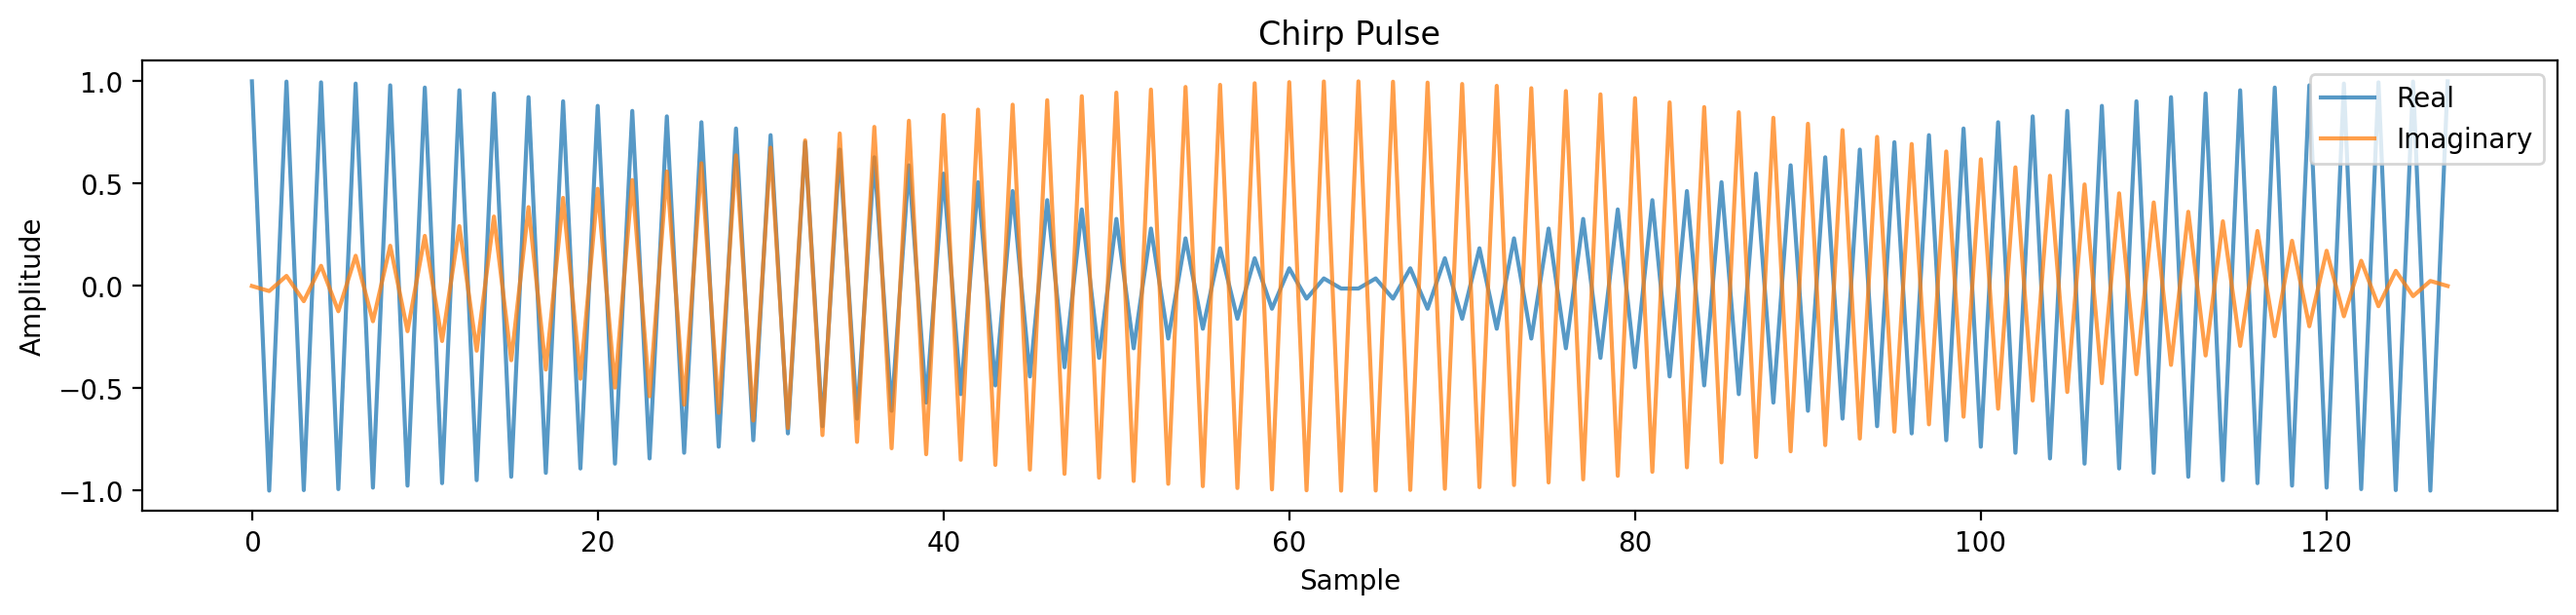

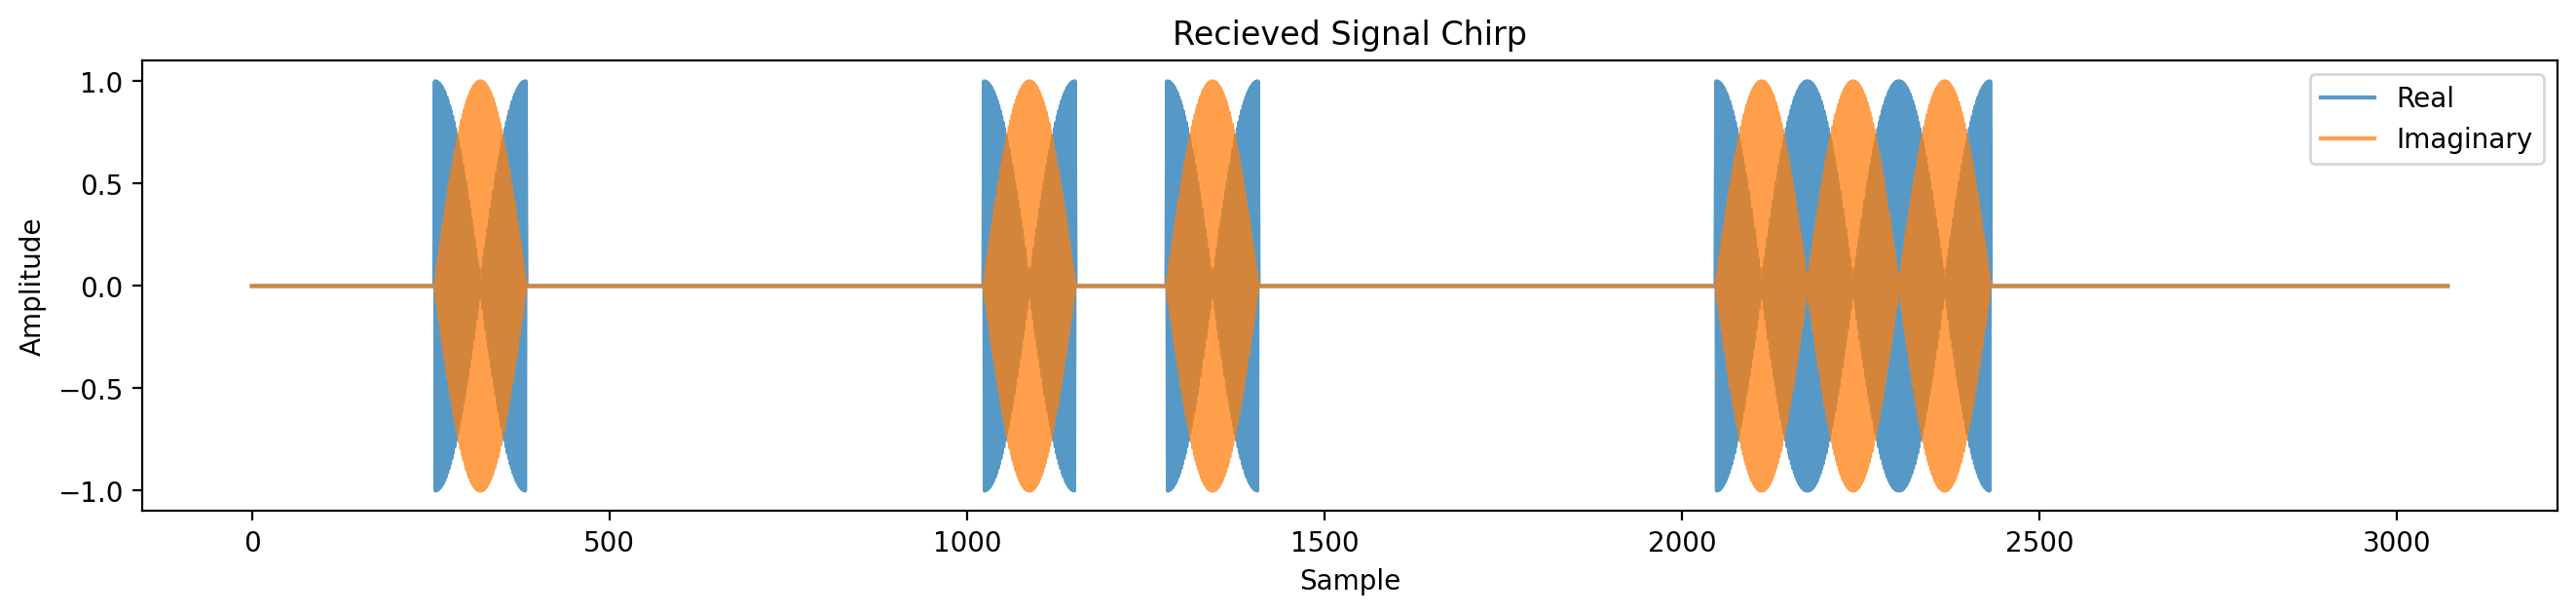

100%|██████████| 3072/3072 [00:00<00:00, 184872.90it/s]


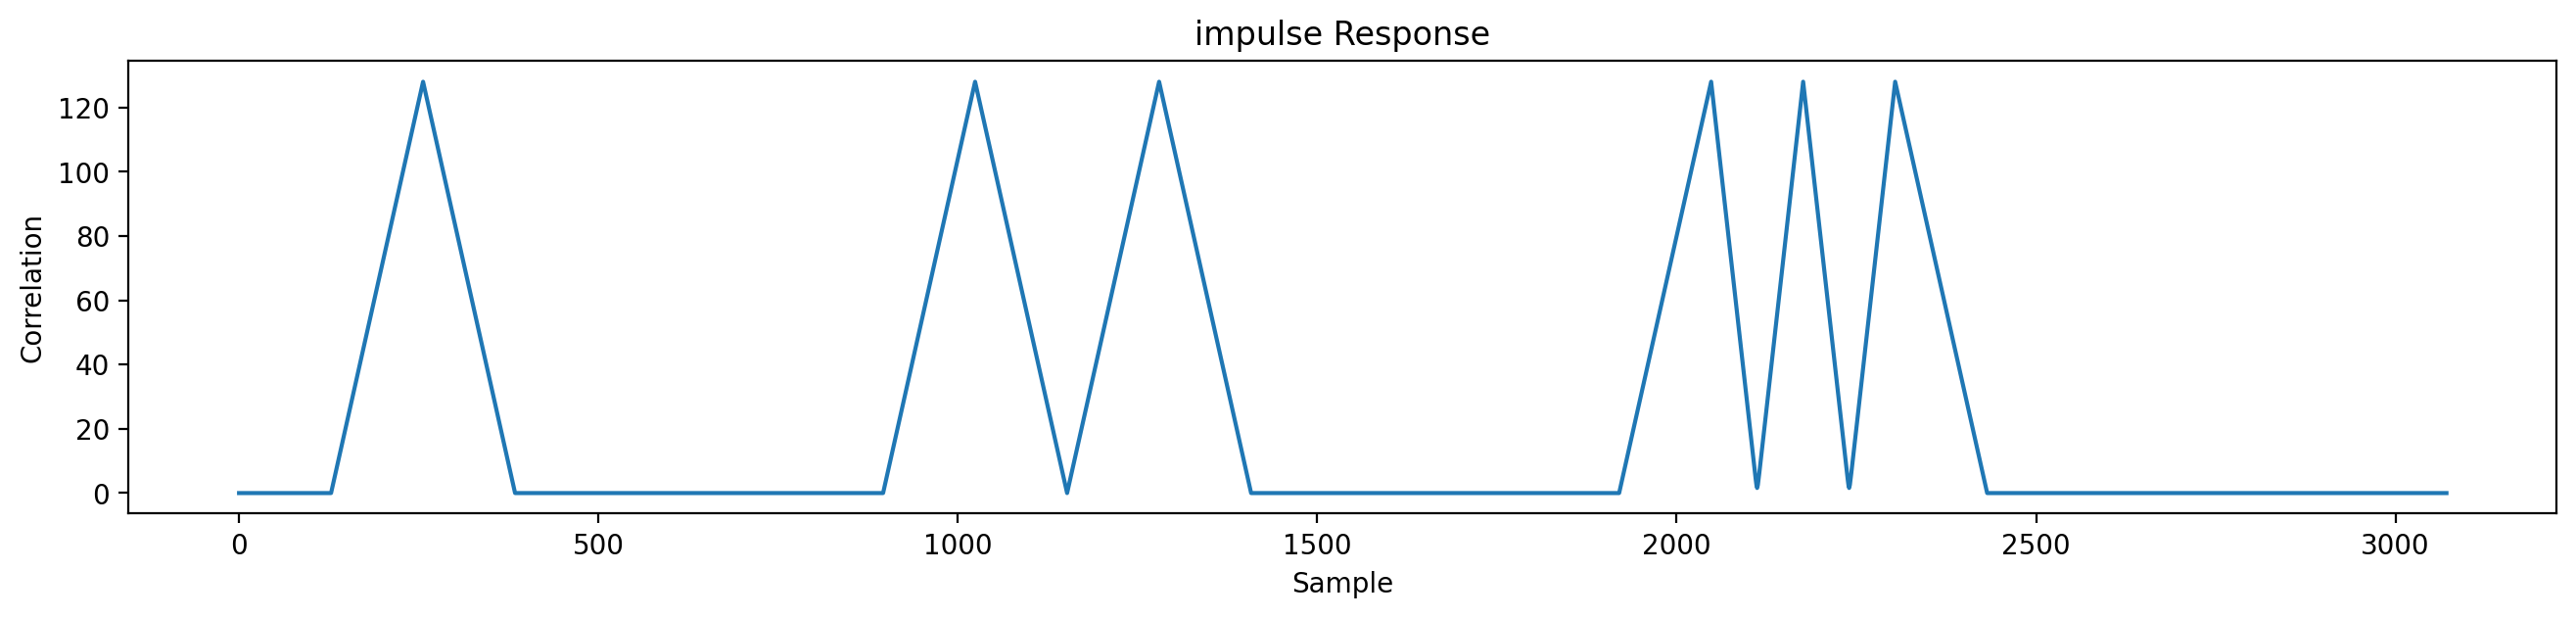

100%|██████████| 3072/3072 [00:00<00:00, 175211.82it/s]


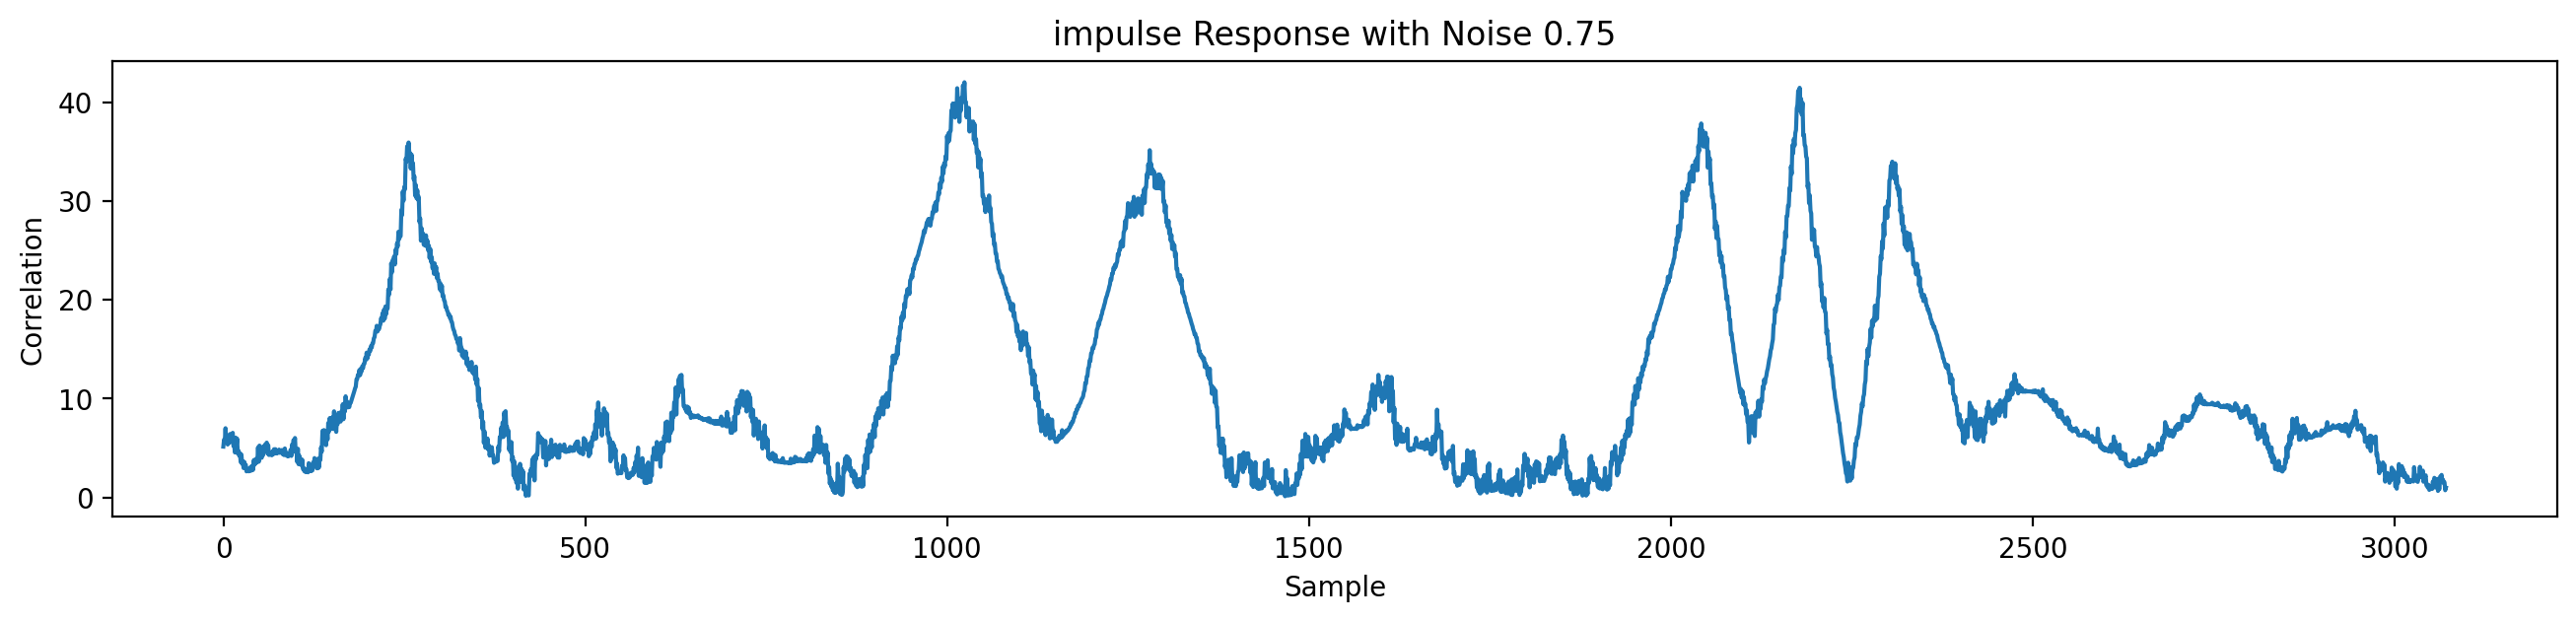

In [12]:
pulse_sample = 128
pulse_times = np.linspace(0, pulse_sample, pulse_sample)
pulse = np.exp(1j * np.pi * pulse_times)

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Chirp Pulse')
plt.plot(pulse.real, label='Real', alpha=0.75)
plt.plot(pulse.imag, label='Imaginary', alpha=0.75)
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(f'section_03_012_chirp_pulse.png', bbox_inches='tight')
plt.show()


respons_signal = np.zeros_like(times, dtype=np.complex64)
for point in points_pulse:
    respons_signal[point:point + pulse_sample] += pulse
    
    
plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Recieved Signal Chirp')
plt.plot(respons_signal.real, label='Real', alpha=0.75)
plt.plot(respons_signal.imag, label='Imaginary', alpha=0.75)
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(f'section_03_013_recieved_signal_chirp.png', bbox_inches='tight')
plt.show()

impulse_response_signal = impulse_response(respons_signal, pulse)

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('impulse Response')
plt.plot(impulse_response_signal,)
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_014_impulse_response_chirp.png', bbox_inches='tight')
plt.show()

impulse_response_signal_noise = impulse_response(respons_signal *ratio + (1 - ratio) * noises, pulse)

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title(f'impulse Response with Noise {1 - ratio:.2f}')
plt.plot(impulse_response_signal_noise,)
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_015_impulse_response_chirp_with_noise_ratio{ratio:.2f}.png', bbox_inches='tight')
plt.show()

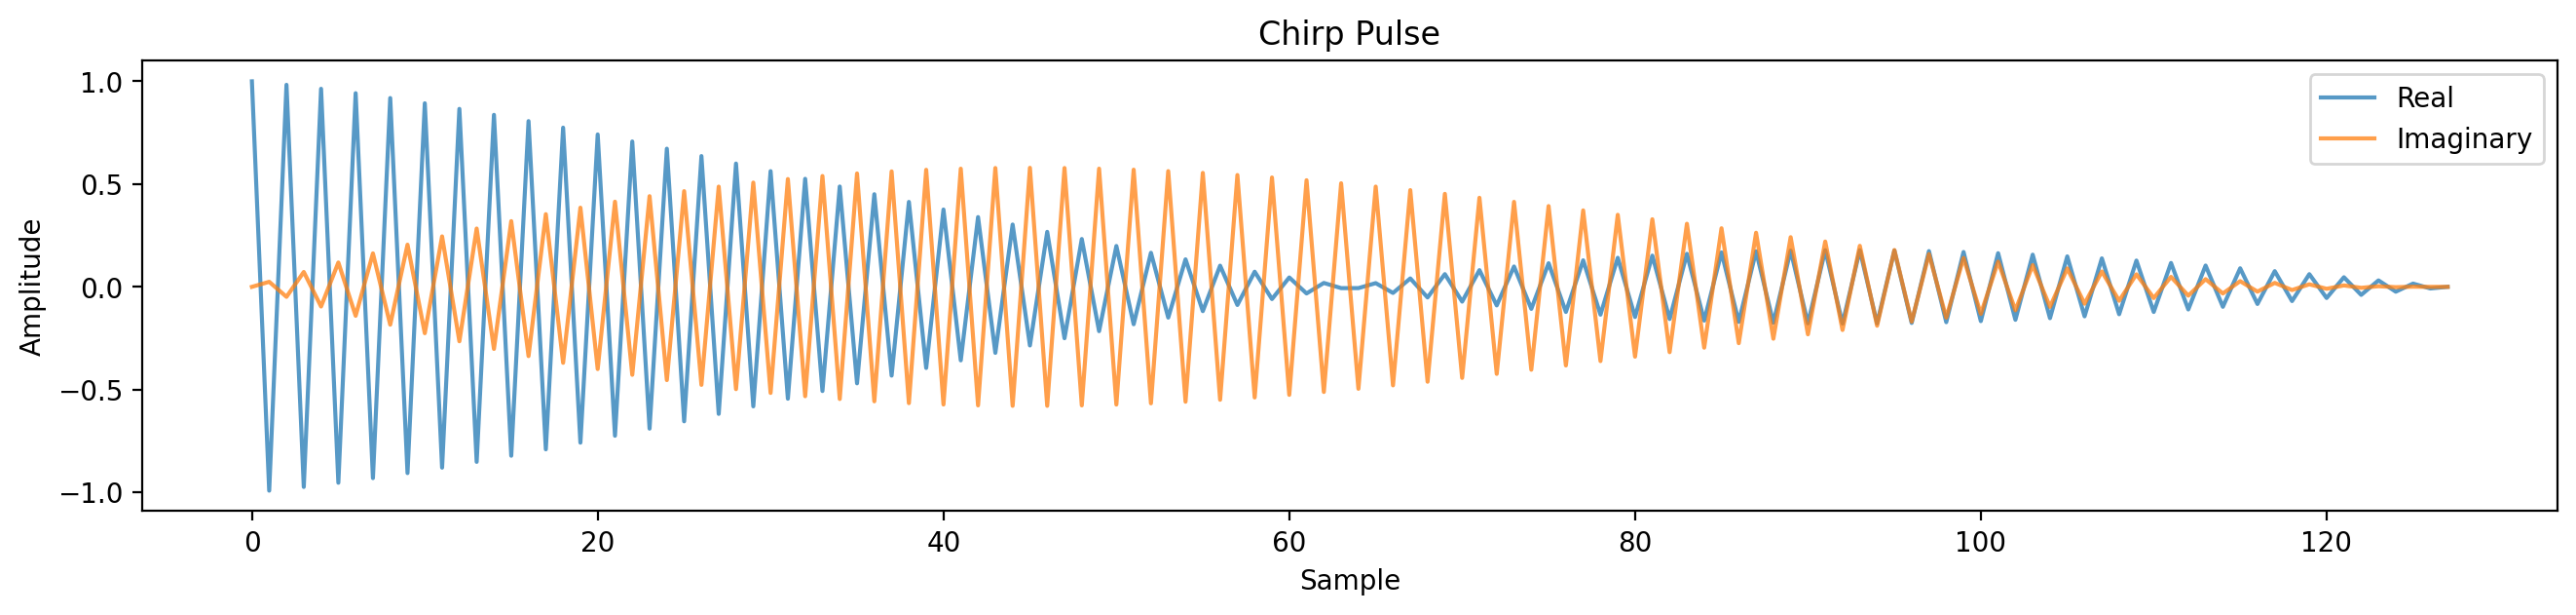

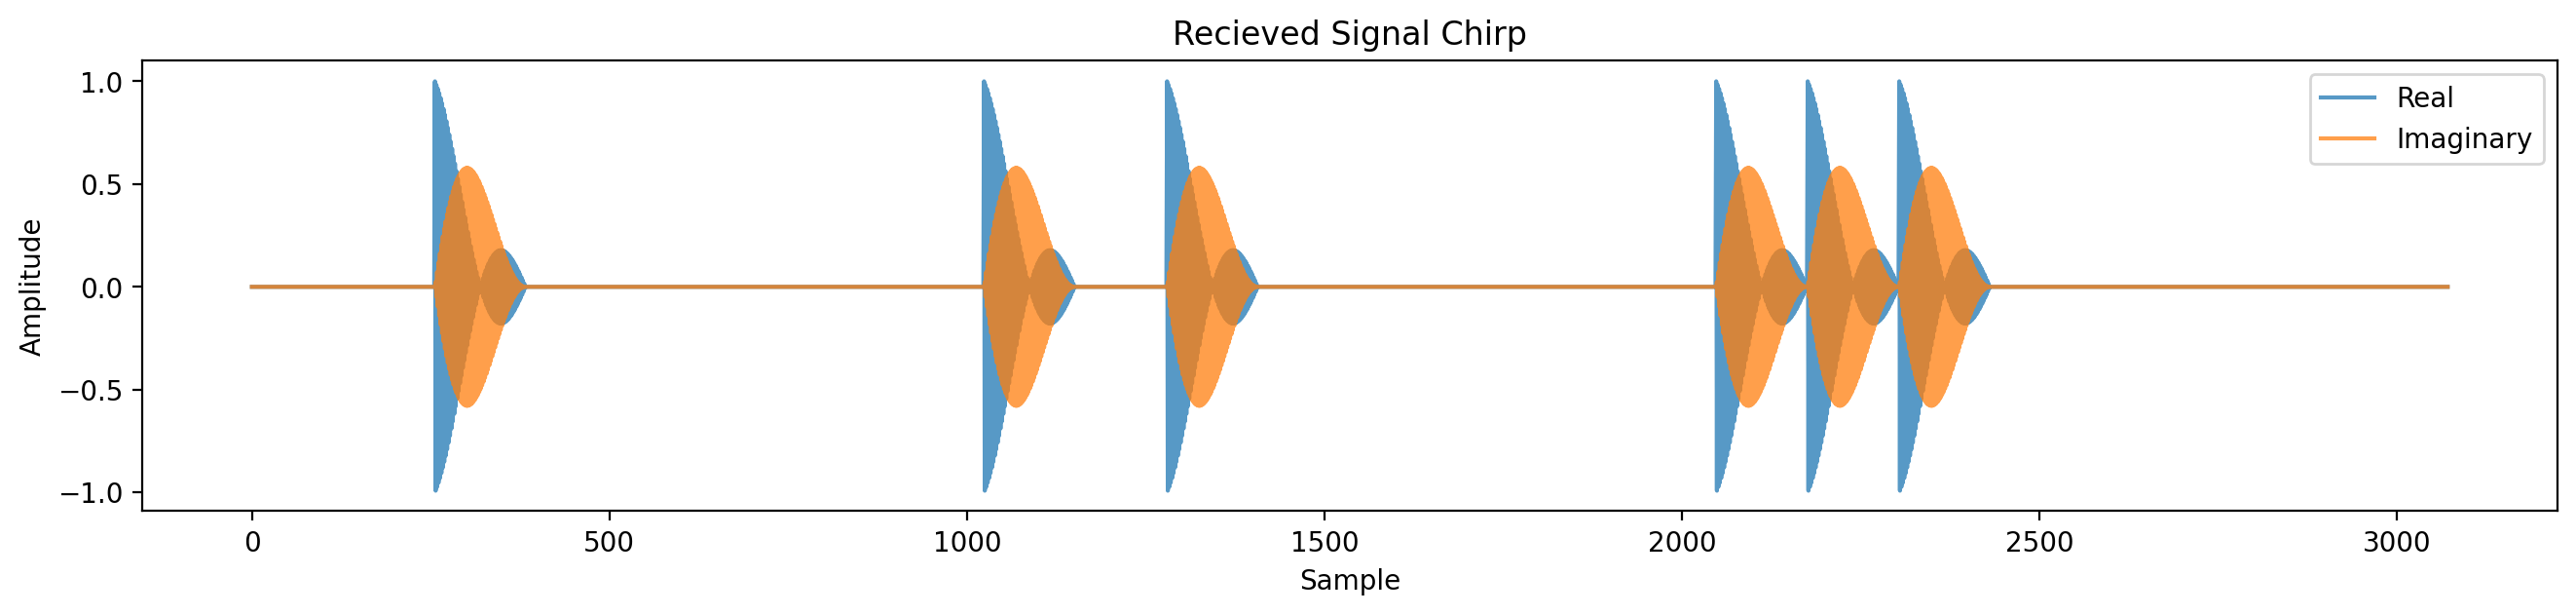

100%|██████████| 3072/3072 [00:00<00:00, 161523.64it/s]


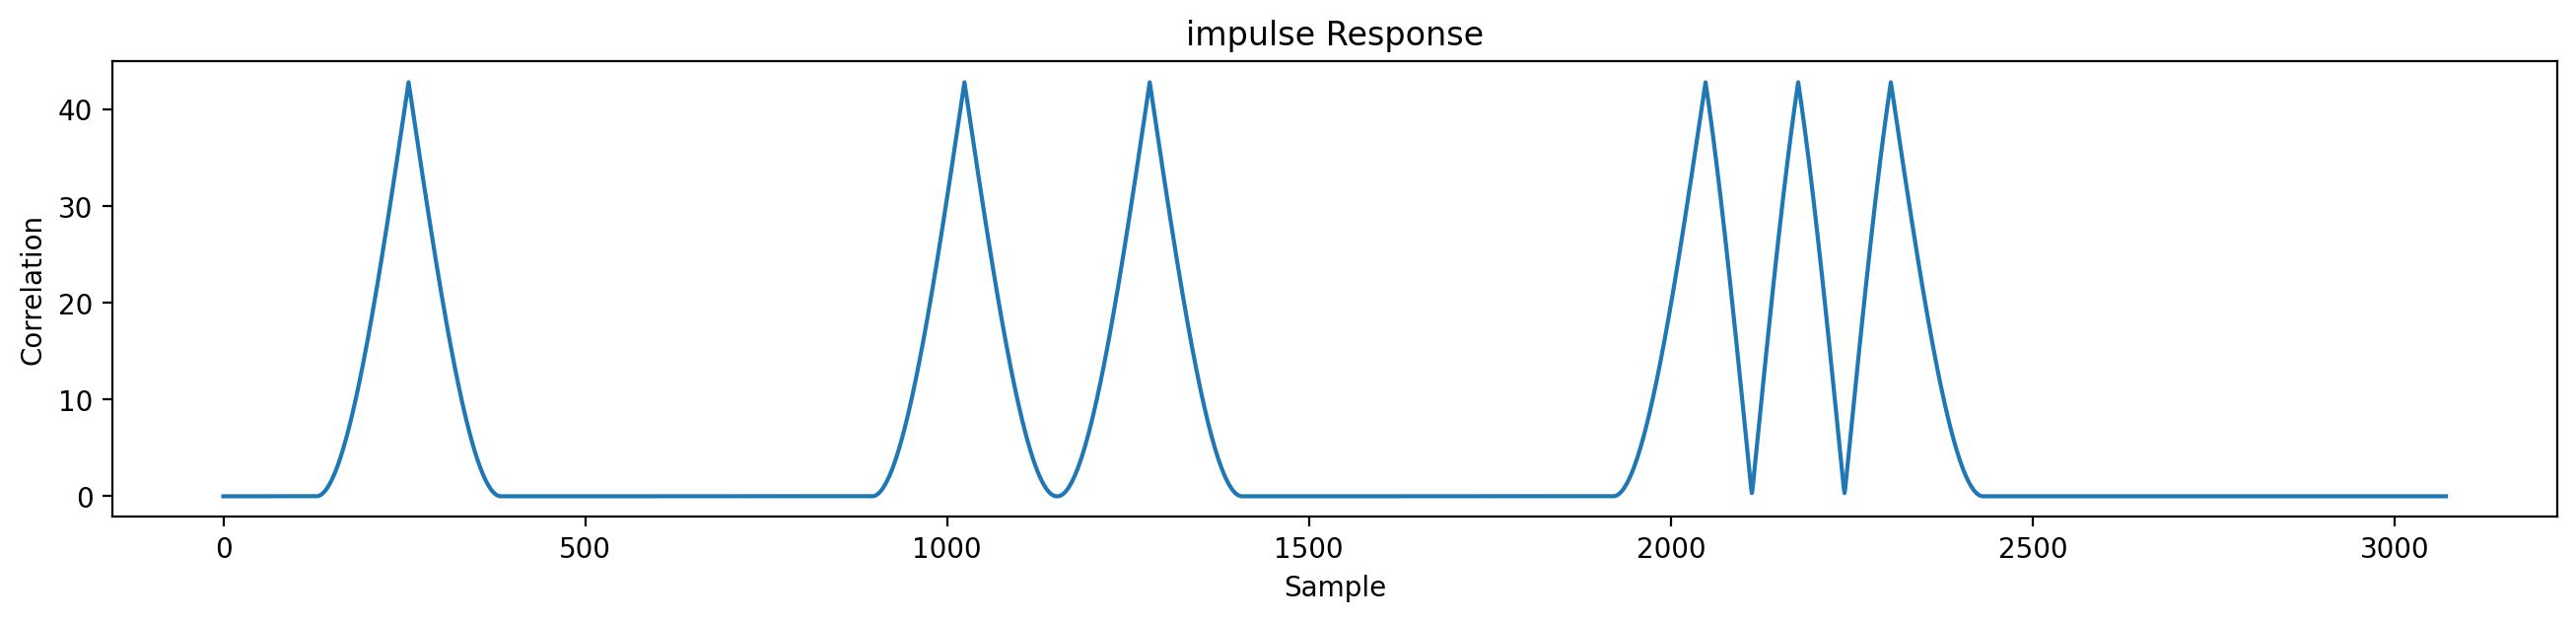

100%|██████████| 3072/3072 [00:00<00:00, 152267.81it/s]


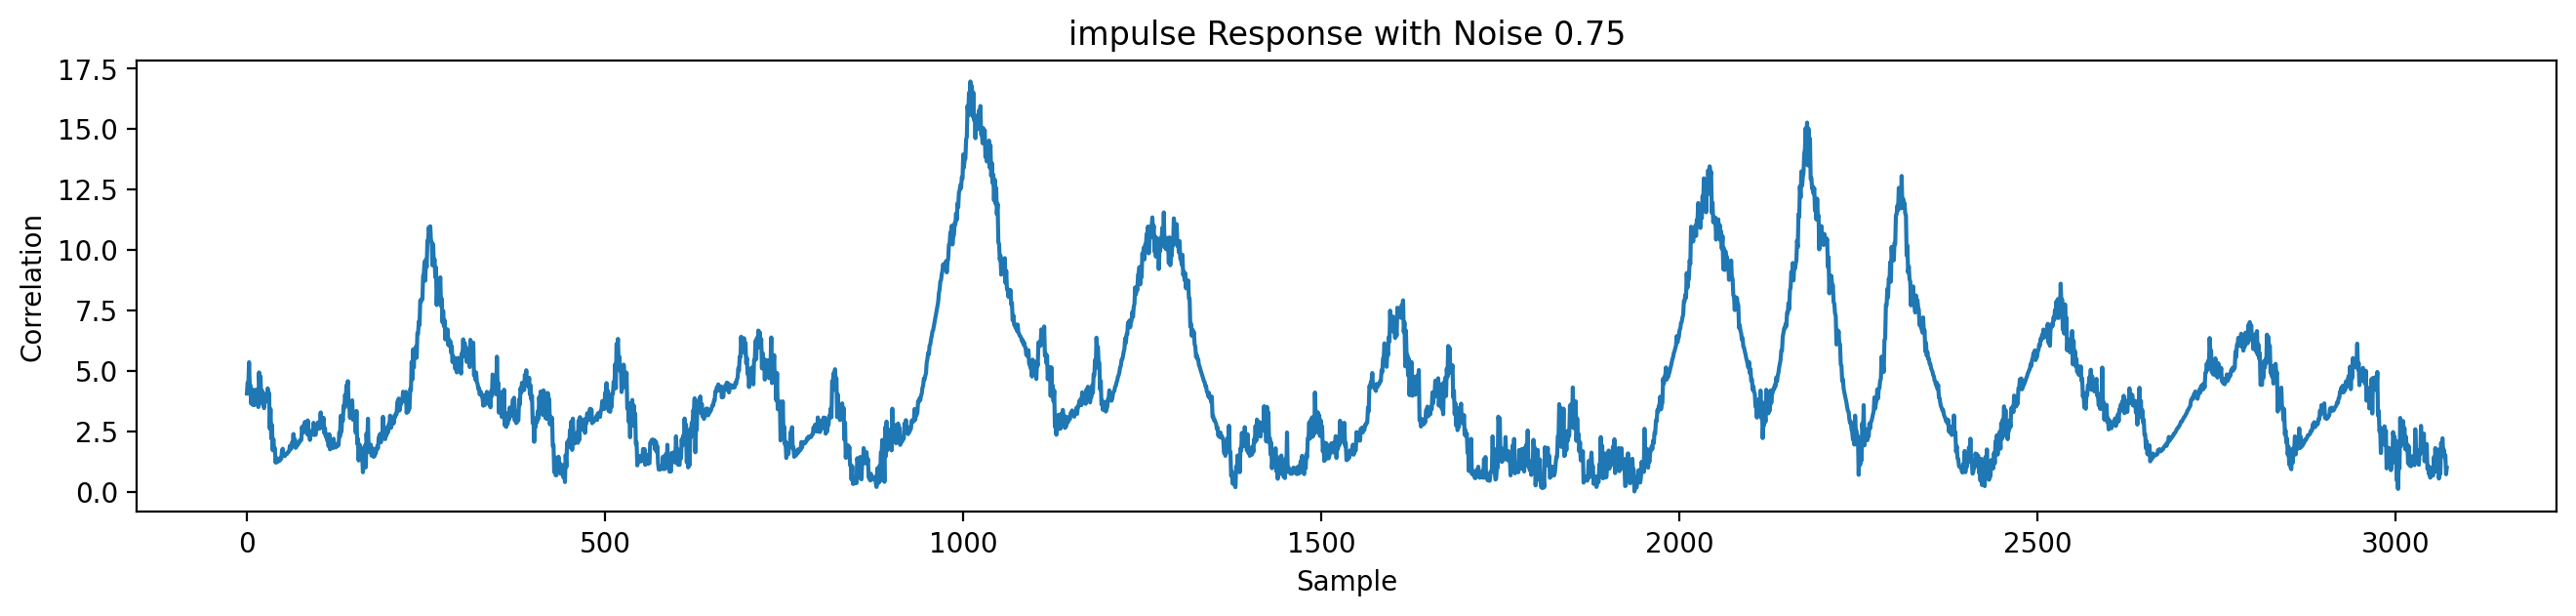

In [13]:
pulse_sample = 128
pulse_times = np.linspace(0, pulse_sample, pulse_sample)
pulse = (np.exp(1j * np.pi * pulse_times) * pulse_times/128)[::-1]

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Chirp Pulse')
plt.plot(pulse.real, label='Real', alpha=0.75)
plt.plot(pulse.imag, label='Imaginary', alpha=0.75)
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(f'section_03_016_chirp_pulse.png', bbox_inches='tight')
plt.show()


respons_signal = np.zeros_like(times, dtype=np.complex64)
for point in points_pulse:
    respons_signal[point:point + pulse_sample] += pulse
    
    
plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Recieved Signal Chirp')
plt.plot(respons_signal.real, label='Real', alpha=0.75)
plt.plot(respons_signal.imag, label='Imaginary', alpha=0.75)
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(f'section_03_017_recieved_signal_chirp.png', bbox_inches='tight')
plt.show()

impulse_response_signal = impulse_response(respons_signal, pulse)

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('impulse Response')
plt.plot(impulse_response_signal,)
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_018_impulse_response_chirp.png', bbox_inches='tight')
plt.show()

impulse_response_signal_noise = impulse_response(respons_signal *ratio + (1 - ratio) * noises, pulse)

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title(f'impulse Response with Noise {1 - ratio:.2f}')
plt.plot(impulse_response_signal_noise,)
plt.xlabel('Sample')
plt.ylabel('Correlation')
plt.savefig(f'section_03_019_impulse_response_chirp_with_noise_ratio{ratio:.2f}.png', bbox_inches='tight')
plt.show()

## Appendix

Numpy implimentation `impulse Response`


In [16]:
def impulse_response(respons_signal, pulse):
    return np.convolve(respons_signal, pulse)

## Movie

In [17]:
import os
import warnings, gc

from scipy.signal import chirp, spectrogram, correlate

warnings.simplefilter('ignore')

In [18]:
skip_step           = 10

t_sec               = 60
t_sec_chirp_start   = 30
tau_p_sec           = 10

fs_sampling         = 1E2
K_r                 = 1.01

noise_top           = 1.
SNR                 = 0.25

assert 0 <  SNR < 1 

tau = np.arange(-tau_p_sec/2, tau_p_sec/2, 1/fs_sampling)
phase = 1j*np.pi*K_r*tau**2
ra_chirp_temp = np.exp(phase)
slice_chirp = slice(int(t_sec_chirp_start*fs_sampling), int((t_sec_chirp_start+tau_p_sec)*fs_sampling))

T = np.arange(0, t_sec, 1/fs_sampling)

noise = np.random.uniform(low=-noise_top, high=noise_top, size=T.shape)
reflect_noise = noise.copy()
noise_tau_sec = np.random.uniform(low=-noise_top, high=noise_top, size=tau.shape)

In [26]:
corr_T = []

for i, t1 in tqdm(enumerate(T), total=len(T)):
    
    # shortcut plot
    if i % skip_step != 0:
        continue
    
    # pulse width time
    if t1 > T.max() - tau_p_sec:
        break
    
    _slice_chirp = slice(round(t1*fs_sampling), round((t1+tau_p_sec)*fs_sampling))

    # reference pulse
    kernel = np.zeros(T.shape)
    kernel[_slice_chirp] = ra_chirp_temp
    
    # correlation
    corr = correlate(kernel.real[_slice_chirp], reflect_noise.real[_slice_chirp], mode='same')
    corr_center = corr[int(len(corr)/2)]
    
    if i == 0:
        corr_T.append(corr_center)
    else:
        corr_T.extend([corr_center]*skip_step)
    
    # visualization
    plt.figure(figsize=(26, 18), dpi=200, facecolor='w', edgecolor='k')
    plt.subplot(6, 1, 1)
    plt.grid(True,)
    plt.plot(tau, corr, alpha=0.8, color='green', label='Correlation Value')
    plt.scatter([0], corr_center, label='Target Center', color='orange')
    plt.scatter([tau[np.argmax(corr)]], corr[np.argmax(corr)], label='Maximum Peak Correlation', color='black')
    plt.legend()
    plt.ylim(-50, 400)
    plt.title(f'Local Correlation Time:{t1: .2f}')
    plt.ylabel('Correlation')
    
    plt.subplot(6, 1, 2)
    plt.plot(T, kernel, color='orange', label='Kernel')
    plt.grid(True,)
    plt.title('Reference Pulse Chirp Signal')
    plt.xlabel('Time axis [sec]')
    plt.ylabel('Amplitude')

    reflect_noise = noise.copy()
    reflect_noise[slice_chirp] = ((1 - SNR)*ra_chirp_temp + SNR*noise_tau_sec)

    plt.subplot(6, 1, 3)
    plt.grid(True,)
    plt.plot(T, reflect_noise.real, 'c')
    plt.xlabel('Time axis [sec]')
    plt.ylabel('Real')
    
    plt.subplot(6, 1, 4)
    plt.grid(True,)
    plt.plot(T, kernel, 'navy', alpha=0.7, label='Kernel')
    plt.plot(T, reflect_noise.real, 'magenta', alpha=0.4, label='Noise Reflect')
    plt.legend()
    plt.ylabel('Amplitude')
    
    plt.subplot(6, 1, 5)
    plt.grid(True,)
    plt.plot(range(i+1), np.array(corr_T), 'b', alpha=0.8, label='Peck')
    plt.scatter([i], corr_center, label='Center Correlation', color='red')
    plt.legend()
    plt.xlim(0, int(len(T) - len(ra_chirp_temp)))
    plt.ylim(-50, 400)
    plt.title('Correlation Value')
    plt.xlabel('Sample [n]')
    plt.ylabel('Correlation')
    
    f, t, Sxx = spectrogram(reflect_noise, fs_sampling)
    plt.subplot(6, 1, 6)
    plt.grid(True,)
    plt.pcolormesh(t, f, Sxx, shading='gouraud', label='spectum', vmax=1e-1, cmap='inferno')
    plt.vlines(t1 + round(tau_p_sec/2), ymin=0, ymax=50, color='red', label='position')
    plt.legend()
    plt.ylabel('Specrtum')
    plt.xlabel('Time [sec]')
    
    plt.tight_layout()
    
    os.makedirs('frames', exist_ok=True)
    plt.savefig(os.path.join('frames', f'impulse_respose_frame_{str(i).zfill(5)}.png'), format='png')
    
    plt.clf()
    plt.close()

 83%|████████▎ | 5000/6000 [12:34<02:30,  6.63it/s]


In [31]:
skip_step = 100
!ffmpeg -r 10  \
    -i frames/impulse_respose_frame_%03d00.png \
    -pix_fmt yuv420p -f mp4 section_03_impulse_response_skip{skip_step}.mp4

ffmpeg version 6.0 Copyright (c) 2000-2023 the FFmpeg developers
  built with Apple clang version 14.0.3 (clang-1403.0.22.14.1)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/6.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --enable-libsoxr --enable-libzmq --enable-libzimg --disab

In [28]:
skip_step = 10
!ffmpeg -r 30  \
    -i frames/impulse_respose_frame_%04d0.png \
    -pix_fmt yuv420p -f mp4 section_03_impulse_response_skip{skip_step}.mp4

ffmpeg version 6.0 Copyright (c) 2000-2023 the FFmpeg developers
  built with Apple clang version 14.0.3 (clang-1403.0.22.14.1)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/6.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --enable-libsoxr --enable-libzmq --enable-libzimg --disab